# Tic Tac Toe agent using tabular Q-learning
## Reinforcement Learning Lab CA mini project
Train a real agent, evaluate it as both X and O, plot the results, and play its learned policy.

This notebook includes all project source. It runs locally in Jupyter with Python, NumPy and Matplotlib, and is compatible with Google Colab. A CPU is sufficient. **Run all cells in order.** Nothing is downloaded. The browser game uses the saved table and does not train during human play.

Student name: __________  |  Roll number: __________  |  Division/batch: __________  |  Performance date: __________


### 1. Prepare the included project
The setup cell restores the Python package, tests and browser UI into a temporary local folder. The readable source files are also provided in the project folder.

In [1]:
# All project source is embedded below. No download, API, or internet connection is used.
import os, sys, json, tempfile
from pathlib import Path
from IPython.display import display, HTML, Image, Markdown
PROJECT_FILES = {'tictactoe/agent.py': '"""Genuine off-policy tabular Q-learning, with rotation/reflection sharing."""\n\nimport json\nfrom pathlib import Path\nimport random\n\nfrom .core import Board, canonicalize, encode_state, legal_actions, transform_state, SYMMETRIES\n\n\nclass QLearningAgent:\n    def __init__(self, alpha: float = 0.15, gamma: float = 0.97, seed: int = 42):\n        self.alpha = alpha\n        self.gamma = gamma\n        self.rng = random.Random(seed)\n        self.q: dict[str, list[float]] = {}\n\n    def values(self, state: str) -> list[float]:\n        key, permutation = canonicalize(state)\n        values = self.q.get(key, [0.0] * 9)\n        return [values[permutation[a]] for a in range(9)]\n\n    def greedy_actions(self, board: Board, mark: int) -> list[int]:\n        actions = legal_actions(board)\n        if not actions:\n            return []\n        values = self.values(encode_state(board, mark))\n        maximum = max(values[a] for a in actions)\n        return [a for a in actions if abs(values[a] - maximum) <= 1e-12]\n\n    def select_action(self, board: Board, agent_mark: int, epsilon: float = 0.0,\n                      rng: random.Random | None = None) -> int:\n        rng = rng or self.rng\n        actions = legal_actions(board)\n        if not actions:\n            raise ValueError("No legal action in a terminal state.")\n        if rng.random() < epsilon:\n            return rng.choice(actions)\n        return rng.choice(self.greedy_actions(board, agent_mark))\n\n    def update(self, state: str, action: int, reward: float,\n               next_state: str | None, done: bool) -> float:\n        """Q <- Q + alpha * [r + gamma * max_legal Q(next) - Q].\n\n        A transition contains an agent move plus an opponent reply, so the next\n        nonterminal state is always the SAME agent\'s next decision. Terminal\n        transitions never bootstrap. Returns the absolute temporal-difference error.\n        """\n        if state[action] != "0":\n            raise ValueError("Cannot learn an illegal action.")\n        key, permutation = canonicalize(state)\n        values = self.q.setdefault(key, [0.0] * 9)\n        canonical_action = permutation[action]\n        target = reward\n        if not done:\n            if next_state is None:\n                raise ValueError("A nonterminal update needs a next state.")\n            next_values = self.values(next_state)\n            actions = [a for a, cell in enumerate(next_state) if cell == "0"]\n            if not actions:\n                raise ValueError("A nonterminal next state needs a legal action.")\n            target += self.gamma * max(next_values[a] for a in actions)\n        td_error = target - values[canonical_action]\n        values[canonical_action] += self.alpha * td_error\n        return abs(td_error)\n\n    def export(self, path: str | Path, metadata: dict | None = None) -> dict:\n        """Expand observed canonical states to raw coordinates for browser inference.\n\n        Symmetric boards can have multiple valid coordinate mappings. We call the\n        same deterministic canonicalization used by training for each raw state;\n        this preserves exactly the trained policy, including symmetric ties.\n        """\n        raw_states = {transform_state(state, p) for state in self.q for p in SYMMETRIES}\n        table = {state: self.values(state) for state in sorted(raw_states)}\n        payload = {\n            "metadata": {"algorithm": "tabular Q-learning", "state_encoding": "0 empty, 1 agent, 2 opponent",\n                         "action_encoding": "row-major indices 0..8", "symmetry_reduction": "8 rotations/reflections",\n                         "canonical_states": len(self.q), "exported_states": len(table),\n                         "greedy_tie_tolerance": 1e-12, "unseen_state_values": 0.0,\n                         "alpha": self.alpha, "gamma": self.gamma, **(metadata or {})},\n            "q_table": table,\n        }\n        path = Path(path)\n        path.parent.mkdir(parents=True, exist_ok=True)\n        path.write_text(json.dumps(payload, separators=(",", ":")), encoding="utf-8")\n        return payload\n\n    @classmethod\n    def load(cls, path: str | Path, seed: int = 42) -> "QLearningAgent":\n        payload = json.loads(Path(path).read_text(encoding="utf-8"))\n        metadata = payload["metadata"]\n        agent = cls(metadata.get("alpha", 0.15), metadata.get("gamma", 0.97), seed)\n        for state, values in payload["q_table"].items():\n            key, permutation = canonicalize(state)\n            if key == state:\n                agent.q[key] = [0.0] * 9\n                for action in range(9):\n                    agent.q[key][permutation[action]] = values[action]\n        return agent\n', 'tictactoe/core.py': '"""Tic-Tac-Toe rules, stationary opponents, and symmetry transforms.\n\nBoard cells: 0 = empty, 1 = X, 2 = O. Actions are row-major indices 0..8.\nOnly training/evaluation opponents use minimax; the learned agent never does.\n"""\n\nfrom functools import lru_cache\nimport random\nfrom typing import TypeAlias\n\nBoard: TypeAlias = tuple[int, ...]\nX, O = 1, 2\nEMPTY_BOARD: Board = (0,) * 9\nWIN_LINES = ((0, 1, 2), (3, 4, 5), (6, 7, 8), (0, 3, 6), (1, 4, 7), (2, 5, 8), (0, 4, 8), (2, 4, 6))\n\n\ndef legal_actions(board: Board) -> list[int]:\n    """Return empty squares, or no actions when the game has ended."""\n    return [] if winner(board) else [i for i, mark in enumerate(board) if mark == 0]\n\n\n@lru_cache(maxsize=None)\ndef winner(board: Board) -> int:\n    for a, b, c in WIN_LINES:\n        if board[a] and board[a] == board[b] == board[c]:\n            return board[a]\n    return 0\n\n\ndef terminal(board: Board) -> bool:\n    return bool(winner(board)) or 0 not in board\n\n\ndef play(board: Board, action: int, mark: int) -> Board:\n    if len(board) != 9 or mark not in (X, O):\n        raise ValueError("Expected a nine-cell board and mark X=1 or O=2.")\n    if terminal(board):\n        raise ValueError("Cannot play after a terminal state.")\n    if action not in range(9) or board[action] != 0:\n        raise ValueError("Action must select an empty cell in 0..8.")\n    return board[:action] + (mark,) + board[action + 1:]\n\n\ndef encode_state(board: Board, agent_mark: int) -> str:\n    """Encode board relative to the agent: 0 empty / 1 self / 2 opponent."""\n    return "".join("0" if m == 0 else "1" if m == agent_mark else "2" for m in board)\n\n\ndef other(mark: int) -> int:\n    return 3 - mark\n\n\ndef _symmetries() -> tuple[tuple[int, ...], ...]:\n    # Each permutation maps an original action to its transformed action.\n    result = []\n    for reflection in (False, True):\n        for rotations in range(4):\n            permutation = []\n            for i in range(9):\n                r, c = divmod(i, 3)\n                if reflection:\n                    c = 2 - c\n                for _ in range(rotations):\n                    r, c = c, 2 - r\n                permutation.append(3 * r + c)\n            result.append(tuple(permutation))\n    return tuple(result)\n\n\nSYMMETRIES = _symmetries()\n\n\ndef transform_state(state: str, permutation: tuple[int, ...]) -> str:\n    result = ["0"] * 9\n    for i, j in enumerate(permutation):\n        result[j] = state[i]\n    return "".join(result)\n\n\n@lru_cache(maxsize=None)\ndef canonicalize(state: str) -> tuple[str, tuple[int, ...]]:\n    """Lexicographically smallest rotation/reflection and original->canonical map."""\n    return min(((transform_state(state, p), p) for p in SYMMETRIES), key=lambda pair: pair[0])\n\n\n@lru_cache(maxsize=None)\ndef minimax_value(board: Board, to_move: int) -> int:\n    """Outcome under perfect play, relative to the player who moves next."""\n    won = winner(board)\n    if won:\n        return 1 if won == to_move else -1\n    actions = legal_actions(board)\n    if not actions:\n        return 0\n    return max(-minimax_value(play(board, a, to_move), other(to_move)) for a in actions)\n\n\n@lru_cache(maxsize=None)\ndef minimax_actions(board: Board, mark: int) -> tuple[int, ...]:\n    actions = legal_actions(board)\n    if not actions:\n        return ()\n    values = [-minimax_value(play(board, a, mark), other(mark)) for a in actions]\n    best = max(values)\n    return tuple(a for a, v in zip(actions, values) if v == best)\n\n\ndef random_action(board: Board, mark: int, rng: random.Random) -> int:\n    return rng.choice(legal_actions(board))\n\n\ndef minimax_action(board: Board, mark: int, rng: random.Random) -> int:\n    return rng.choice(minimax_actions(board, mark))\n\n\ndef tactical_action(board: Board, mark: int, rng: random.Random) -> int:\n    """Win, block, take center, take a corner, otherwise take an edge."""\n    actions = legal_actions(board)\n    for target in (mark, other(mark)):\n        winning = [a for a in actions if winner(play(board, a, target)) == target]\n        if winning:\n            return rng.choice(winning)\n    if 4 in actions:\n        return 4\n    corners = [a for a in actions if a in (0, 2, 6, 8)]\n    return rng.choice(corners or actions)\n\n\nOPPONENTS = {"random": random_action, "tactical": tactical_action, "minimax": minimax_action}\n\n\ndef mixture_action(board: Board, mark: int, rng: random.Random,\n                   weights: tuple[float, float, float]) -> int:\n    """Choose an opponent policy independently on every move (stationary mixture)."""\n    name = rng.choices(tuple(OPPONENTS), weights=weights, k=1)[0]\n    return OPPONENTS[name](board, mark, rng)\n', 'tictactoe/evaluate.py': '"""Held-out evaluation and an exact adversarial audit of the learned policy."""\n\nfrom functools import lru_cache\nimport random\n\nfrom .agent import QLearningAgent\nfrom .core import EMPTY_BOARD, X, O, Board, OPPONENTS, encode_state, legal_actions, other, play, terminal, winner\n\n\ndef evaluate(agent: QLearningAgent, games_per_role: int = 1000, seed: int = 2026,\n             draw_reward: float = 0.3, loss_reward: float = -1.0) -> dict:\n    """Evaluate with fresh RNGs; epsilon=0; tie choices remain random."""\n    results = {}\n    for index, (name, opponent) in enumerate(OPPONENTS.items()):\n        role_results = {}\n        for mark, role in ((X, "X"), (O, "O")):\n            rng = random.Random(seed + 10000 * index + 100 * mark)\n            wins = draws = losses = total_moves = 0\n            for _ in range(games_per_role):\n                board, turn, moves = EMPTY_BOARD, X, 0\n                while not terminal(board):\n                    action = agent.select_action(board, mark, epsilon=0.0, rng=rng) if turn == mark else opponent(board, turn, rng)\n                    board = play(board, action, turn)\n                    moves += 1\n                    turn = other(turn)\n                won = winner(board)\n                wins += won == mark\n                losses += won == other(mark)\n                draws += won == 0\n                total_moves += moves\n            role_results[role] = _metrics(wins, draws, losses, total_moves, draw_reward, loss_reward)\n        role_results["combined"] = _metrics(\n            sum(v["wins"] for v in role_results.values()),\n            sum(v["draws"] for v in role_results.values()),\n            sum(v["losses"] for v in role_results.values()),\n            sum(v["total_board_moves"] for v in role_results.values()), draw_reward, loss_reward)\n        results[name] = role_results\n    return results\n\n\ndef _metrics(wins, draws, losses, total_moves, draw_reward, loss_reward):\n    games = wins + draws + losses\n    reward = wins + draw_reward * draws + loss_reward * losses\n    return {"games": games, "wins": wins, "draws": draws, "losses": losses,\n            "win_rate": wins / games, "draw_rate": draws / games, "loss_rate": losses / games,\n            "non_loss_rate": (wins + draws) / games, "cumulative_reward": reward,\n            "average_reward": reward / games, "total_board_moves": total_moves,\n            "average_board_moves": total_moves / games}\n\n\ndef adversarial_audit(agent: QLearningAgent) -> dict:\n    """Exactly evaluate an opponent that maximizes this agent\'s loss probability.\n\n    Unlike ordinary minimax-versus-minimax optimal actions, this adversary may\n    choose traps to exploit a fallible learned policy. Agent maximal-Q ties are\n    averaged uniformly; opponent choices maximize loss, then minimize wins.\n    Returns exact tree probabilities from an empty board for each playing role.\n    """\n    result = {}\n    for agent_mark, role in ((X, "X"), (O, "O")):\n        seen_states: set[str] = set()\n        unknown_states: set[str] = set()\n\n        @lru_cache(maxsize=None)\n        def visit(board: Board, turn: int) -> tuple[float, float, float]:\n            won = winner(board)\n            if won:\n                return (1., 0., 0.) if won == agent_mark else (0., 0., 1.)\n            if 0 not in board:\n                return (0., 1., 0.)\n            if turn == agent_mark:\n                state = encode_state(board, agent_mark)\n                seen_states.add(state)\n                from .core import canonicalize\n                if canonicalize(state)[0] not in agent.q:\n                    unknown_states.add(state)\n                choices = agent.greedy_actions(board, agent_mark)\n                children = [visit(play(board, action, turn), other(turn)) for action in choices]\n                return tuple(sum(child[i] for child in children) / len(children) for i in range(3))\n            children = [visit(play(board, action, turn), other(turn)) for action in legal_actions(board)]\n            return max(children, key=lambda scores: (scores[2], -scores[0]))\n\n        win, draw, loss = visit(EMPTY_BOARD, X)\n        result[role] = {"win_probability": win, "draw_probability": draw, "loss_probability": loss,\n                        "reachable_agent_states": len(seen_states), "unseen_agent_states": len(unknown_states),\n                        "tree_nodes": visit.cache_info().currsize,\n                        "unbeatable_from_empty_board": loss < 1e-12}\n    return result\n', 'tictactoe/train.py': '"""Reproducible training/evaluation CLI: python -m tictactoe.train."""\n\nimport argparse\nfrom dataclasses import asdict, dataclass\nfrom datetime import datetime, timezone\nimport csv\nimport json\nfrom pathlib import Path\nimport platform\nimport random\nimport time\n\nfrom .agent import QLearningAgent\nfrom .core import EMPTY_BOARD, X, O, encode_state, mixture_action, other, play, terminal, winner\nfrom .evaluate import adversarial_audit, evaluate\n\n\n@dataclass\nclass TrainingConfig:\n    episodes: int = 160_000\n    seed: int = 42\n    alpha: float = 0.15\n    gamma: float = 0.97\n    epsilon_start: float = 1.0\n    epsilon_end: float = 0.03\n    epsilon_decay_fraction: float = 0.85\n    win_reward: float = 1.0\n    draw_reward: float = 0.3\n    loss_reward: float = -1.0\n    random_weight: float = 0.25\n    tactical_weight: float = 0.15\n    minimax_weight: float = 0.60\n    history_interval: int = 1000\n    evaluation_interval: int = 5000\n    checkpoint_games_per_role: int = 200\n    final_games_per_role: int = 2000\n    evaluation_seed: int = 2026\n\n\ndef epsilon_at(episode: int, config: TrainingConfig) -> float:\n    """Linear annealing followed by a nonzero exploration floor."""\n    fraction = min(1.0, episode / max(1., config.episodes * config.epsilon_decay_fraction))\n    return config.epsilon_start + fraction * (config.epsilon_end - config.epsilon_start)\n\n\ndef train(config: TrainingConfig, progress: bool = True):\n    if config.episodes < 1 or config.history_interval < 1 or config.evaluation_interval < 1:\n        raise ValueError("Episode counts and intervals must be positive.")\n    started = time.perf_counter()\n    agent = QLearningAgent(config.alpha, config.gamma, config.seed)\n    environment_rng = random.Random(config.seed + 1)\n    history, checkpoints = [], []\n    block = {"episodes": 0, "wins": 0, "draws": 0, "losses": 0, "reward": 0., "moves": 0, "decisions": 0, "td_error": 0.}\n    total_reward = 0.\n    weights = (config.random_weight, config.tactical_weight, config.minimax_weight)\n    for episode in range(1, config.episodes + 1):\n        mark = X if episode % 2 else O\n        board, moves, decisions, error = EMPTY_BOARD, 0, 0, 0.\n        if mark == O:\n            board = play(board, mixture_action(board, X, environment_rng, weights), X)\n            moves += 1\n        epsilon = epsilon_at(episode - 1, config)\n        while True:\n            state = encode_state(board, mark)\n            action = agent.select_action(board, mark, epsilon)\n            board = play(board, action, mark)\n            moves += 1\n            decisions += 1\n            if not terminal(board):\n                response = mixture_action(board, other(mark), environment_rng, weights)\n                board = play(board, response, other(mark))\n                moves += 1\n            done = terminal(board)\n            won = winner(board)\n            reward = ((config.win_reward if won == mark else config.loss_reward) if won else config.draw_reward) if done else 0.\n            error += agent.update(state, action, reward, None if done else encode_state(board, mark), done)\n            if done:\n                break\n        block["episodes"] += 1\n        block["wins"] += won == mark\n        block["draws"] += won == 0\n        block["losses"] += won == other(mark)\n        block["reward"] += reward\n        block["moves"] += moves\n        block["decisions"] += decisions\n        block["td_error"] += error\n        total_reward += reward\n        if episode % config.history_interval == 0 or episode == config.episodes:\n            count = block["episodes"]\n            history.append({"episode": episode, "window_episodes": count, "epsilon": epsilon,\n                            "average_reward": block["reward"] / count, "cumulative_reward": total_reward,\n                            "win_rate": block["wins"] / count, "draw_rate": block["draws"] / count,\n                            "loss_rate": block["losses"] / count,\n                            "non_loss_rate": (block["wins"] + block["draws"]) / count,\n                            "average_board_moves": block["moves"] / count,\n                            "average_agent_decisions": block["decisions"] / count,\n                            "mean_absolute_td_error": block["td_error"] / block["decisions"],\n                            "canonical_states": len(agent.q)})\n            block = {key: 0 for key in block}\n        if episode % config.evaluation_interval == 0 or episode == config.episodes:\n            measurements = evaluate(agent, config.checkpoint_games_per_role, config.evaluation_seed,\n                                    config.draw_reward, config.loss_reward)\n            for name, values in measurements.items():\n                checkpoints.append({"episode": episode, "opponent": name, **values["combined"]})\n            if progress:\n                values = " | ".join(f"{name}: {v[\'combined\'][\'non_loss_rate\']:.1%} non-loss" for name, v in measurements.items())\n                print(f"{episode:,}/{config.episodes:,} episodes | epsilon={epsilon:.3f} | {values}", flush=True)\n    return agent, history, checkpoints, time.perf_counter() - started\n\n\ndef write_csv(path: Path, rows: list[dict]):\n    with path.open("w", newline="", encoding="utf-8") as output:\n        writer = csv.DictWriter(output, fieldnames=list(rows[0]))\n        writer.writeheader()\n        writer.writerows(rows)\n\n\ndef make_plots(history: list[dict], checkpoints: list[dict], output: Path):\n    import matplotlib\n    matplotlib.use("Agg")\n    import matplotlib.pyplot as plt\n    plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10, "axes.spines.top": False,\n                         "axes.spines.right": False, "figure.facecolor": "#f8fafc", "axes.facecolor": "#ffffff"})\n    output.mkdir(exist_ok=True)\n    xs = [row["episode"] for row in history]\n    def save(name, title, ylabel, series, ylim=None):\n        fig, ax = plt.subplots(figsize=(8.2, 4.3), constrained_layout=True)\n        colors = ("#2563eb", "#e07025", "#0d9488")\n        for (label, xx, yy), color in zip(series, colors):\n            ax.plot(xx, yy, label=label, color=color, linewidth=2)\n        ax.set(title=title, xlabel="Training episode", ylabel=ylabel)\n        ax.grid(alpha=.2)\n        ax.ticklabel_format(axis="x", style="plain")\n        if ylim:\n            ax.set_ylim(*ylim)\n        ax.legend(frameon=False, loc="best")\n        fig.savefig(output / name, dpi=170)\n        plt.close(fig)\n    save("reward_vs_episode.png", "Training reward improves as exploration falls", "Mean terminal reward / episode",\n         [("Training window (1,000 episodes)", xs, [r["average_reward"] for r in history])])\n    save("success_vs_episode.png", "Held-out greedy evaluation: non-loss rate", "Wins + draws / games",\n         [(name.title(), [r["episode"] for r in checkpoints if r["opponent"] == name],\n           [r["non_loss_rate"] for r in checkpoints if r["opponent"] == name]) for name in ("random", "tactical", "minimax")], (0, 1.03))\n    save("steps_vs_episode.png", "Episode length during training", "Mean number of moves",\n         [("Board moves (both players)", xs, [r["average_board_moves"] for r in history]),\n          ("Agent decisions", xs, [r["average_agent_decisions"] for r in history])])\n    save("td_error_vs_episode.png", "Temporal-difference error under a stochastic opponent", "Mean absolute TD error / update",\n         [("Training window (1,000 episodes)", xs, [r["mean_absolute_td_error"] for r in history])])\n\n\ndef run_experiment(config: TrainingConfig, output_dir: str | Path = "artifacts", plots: bool = True,\n                   progress: bool = True) -> dict:\n    output = Path(output_dir)\n    output.mkdir(parents=True, exist_ok=True)\n    baseline = evaluate(QLearningAgent(seed=config.seed), config.final_games_per_role,\n                        config.evaluation_seed + 1_000_000, config.draw_reward, config.loss_reward)\n    agent, history, checkpoints, elapsed = train(config, progress)\n    final = evaluate(agent, config.final_games_per_role, config.evaluation_seed + 1_000_000,\n                     config.draw_reward, config.loss_reward)\n    audit = adversarial_audit(agent)\n    config_dict = asdict(config)\n    payload = agent.export(output / "q_table.json", {"seed": config.seed, "episodes": config.episodes,\n                          "rewards": {"win": config.win_reward, "draw": config.draw_reward, "loss": config.loss_reward, "ongoing": 0},\n                          "training_opponents": {"random": config.random_weight, "tactical": config.tactical_weight, "minimax": config.minimax_weight}})\n    evaluation = {"evaluation_seed": config.evaluation_seed + 1_000_000,\n                  "games_per_role_per_opponent": config.final_games_per_role,\n                  "policy": "epsilon=0, uniformly random maximal-Q ties; no search at inference",\n                  "baseline": baseline, "trained": final, "adversarial_audit": audit}\n    summary = {"parameters": config_dict, "training_elapsed_seconds": elapsed,\n               "created_utc": datetime.now(timezone.utc).isoformat(),\n               "python_version": platform.python_version(), "platform": platform.platform(),\n               "canonical_states": payload["metadata"]["canonical_states"],\n               "exported_states": payload["metadata"]["exported_states"],\n               "final_training_window": history[-1], "initial_training_window": history[0],\n               "evaluation": evaluation,\n               "methodology": {"state": "9 cells relative to agent (0 empty, 1 self, 2 opponent)",\n                               "transition": "agent action plus opponent response; next state belongs to same agent",\n                               "symmetry": "8 rotations/reflections canonicalized during learning; raw states expanded for browser",\n                               "opponent_mixture": "policy sampled independently for each opponent move",\n                               "roles": "agent alternates X and O each episode",\n                               "checkpoint_seed": config.evaluation_seed,\n                               "final_seed": config.evaluation_seed + 1_000_000,\n                               "baseline": "all Q-values zero, epsilon=0, uniform legal ties (random policy)",\n                               "success_definition": "non-loss rate = (wins + draws) / games"}}\n    if plots:\n        make_plots(history, checkpoints, output / "plots")\n        import matplotlib\n        import numpy\n        summary["library_versions"] = {"numpy": numpy.__version__, "matplotlib": matplotlib.__version__}\n    write_csv(output / "training_history.csv", history)\n    write_csv(output / "evaluation_checkpoints.csv", checkpoints)\n    (output / "evaluation.json").write_text(json.dumps(evaluation, indent=2), encoding="utf-8")\n    (output / "training_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")\n    if progress:\n        print(json.dumps({"training_seconds": round(elapsed, 2), "canonical_states": len(agent.q),\n                          "final": {k: v["combined"] for k, v in final.items()}, "adversarial_audit": audit}, indent=2))\n    return summary\n\n\ndef main():\n    parser = argparse.ArgumentParser(description=__doc__)\n    parser.add_argument("--episodes", type=int, default=160_000)\n    parser.add_argument("--seed", type=int, default=42)\n    parser.add_argument("--output", default="artifacts")\n    parser.add_argument("--evaluation-games", type=int, default=2000, help="Games per role and opponent in final evaluation")\n    parser.add_argument("--no-plots", action="store_true")\n    args = parser.parse_args()\n    run_experiment(TrainingConfig(episodes=args.episodes, seed=args.seed, final_games_per_role=args.evaluation_games), args.output, not args.no_plots)\n\n\nif __name__ == "__main__":\n    main()\n', 'tictactoe/__init__.py': '"""Small, dependency-free Tic-Tac-Toe environment and tabular Q-learning agent."""\n\nfrom .core import Board, EMPTY_BOARD, X, O, legal_actions, play, winner, encode_state\nfrom .agent import QLearningAgent\n\n__all__ = ["Board", "EMPTY_BOARD", "X", "O", "legal_actions", "play", "winner", "encode_state", "QLearningAgent"]\n', 'tests/test_rl.py': '"""Meaningful rules, TD-update, export, determinism, and opponent checks."""\n\nimport json\nimport random\nfrom pathlib import Path\nimport tempfile\nimport unittest\n\nfrom tictactoe import EMPTY_BOARD, QLearningAgent, X, O, encode_state, legal_actions, play, winner\nfrom tictactoe.core import WIN_LINES, canonicalize, minimax_actions, minimax_value, SYMMETRIES, transform_state\nfrom tictactoe.evaluate import adversarial_audit\nfrom tictactoe.train import TrainingConfig, train\n\n\nclass RulesTests(unittest.TestCase):\n    def test_all_eight_winning_lines_for_both_players(self):\n        for mark in (X, O):\n            for line in WIN_LINES:\n                board = tuple(mark if i in line else 0 for i in range(9))\n                self.assertEqual(winner(board), mark)\n                self.assertEqual(legal_actions(board), [])\n\n    def test_draw_and_legal_action_mask(self):\n        draw = (1, 2, 1, 1, 2, 2, 2, 1, 1)\n        self.assertEqual(winner(draw), 0)\n        self.assertEqual(legal_actions(draw), [])\n        with self.assertRaises(ValueError):\n            play(draw, 0, X)\n        with self.assertRaises(ValueError):\n            play((1, 0, 0, 0, 0, 0, 0, 0, 0), 0, O)\n\n    def test_perspective_and_symmetry(self):\n        board = (1, 0, 2, 0, 1, 0, 2, 0, 0)\n        self.assertEqual(encode_state(board, X), "102010200")\n        self.assertEqual(encode_state(board, O), "201020100")\n        key = canonicalize(encode_state(board, X))[0]\n        self.assertEqual(len(set(SYMMETRIES)), 8)\n        for permutation in SYMMETRIES:\n            self.assertEqual(canonicalize(transform_state(encode_state(board, X), permutation))[0], key)\n\n    def test_minimax_empty_board_draw_and_forced_block(self):\n        self.assertEqual(minimax_value(EMPTY_BOARD, X), 0)\n        self.assertEqual(minimax_actions((1, 1, 0, 0, 2, 0, 0, 0, 0), O), (2,))\n\n\nclass LearningTests(unittest.TestCase):\n    def test_terminal_update_never_bootstraps(self):\n        agent = QLearningAgent(alpha=.5, gamma=.9)\n        agent.q["000000000"] = [100.] * 9\n        state = "110220000"\n        agent.update(state, 2, 1., "000000000", done=True)\n        self.assertAlmostEqual(agent.values(state)[2], .5)\n\n    def test_nonterminal_update_masks_illegal_next_actions(self):\n        agent = QLearningAgent(alpha=.5, gamma=.9)\n        next_state = "120000000"\n        key, p = canonicalize(next_state)\n        agent.q[key] = [0.] * 9\n        agent.q[key][p[0]] = 999.  # occupied: must never enter max target\n        agent.q[key][p[1]] = 999.\n        agent.q[key][p[2]] = .8\n        agent.update("000000000", 0, 0., next_state, done=False)\n        self.assertAlmostEqual(agent.values("000000000")[0], .36)\n\n    def test_policy_masks_occupied_actions_and_randomizes_ties(self):\n        agent = QLearningAgent(seed=12)\n        board = (1, 2, 0, 0, 0, 0, 0, 0, 0)\n        key, p = canonicalize(encode_state(board, X))\n        agent.q[key] = [0.] * 9\n        agent.q[key][p[0]] = 999.\n        self.assertEqual(set(agent.select_action(board, X) for _ in range(300)), set(range(2, 9)))\n\n    def test_export_and_reload_preserve_values_in_every_orientation(self):\n        agent = QLearningAgent(alpha=.4)\n        agent.update("102000000", 4, .6, None, True)\n        agent.update("000000000", 0, 1., None, True)\n        with tempfile.TemporaryDirectory() as directory:\n            path = Path(directory) / "q.json"\n            payload = agent.export(path)\n            restored = QLearningAgent.load(path)\n            self.assertEqual(set(payload), {"metadata", "q_table"})\n            for state, exported_values in payload["q_table"].items():\n                self.assertEqual(agent.values(state), exported_values)\n                self.assertEqual(restored.values(state), exported_values)\n\n    def test_training_is_reproducible_and_evaluation_is_nonmutating(self):\n        config = TrainingConfig(episodes=300, history_interval=100, evaluation_interval=300,\n                                checkpoint_games_per_role=10, final_games_per_role=10)\n        one, history_one, checkpoints_one, _ = train(config, progress=False)\n        two, history_two, checkpoints_two, _ = train(config, progress=False)\n        self.assertEqual(one.q, two.q)\n        self.assertEqual(history_one, history_two)\n        self.assertEqual(checkpoints_one, checkpoints_two)\n        before = json.dumps(one.q, sort_keys=True)\n        audit = adversarial_audit(one)\n        self.assertEqual(before, json.dumps(one.q, sort_keys=True))\n        for result in audit.values():\n            self.assertAlmostEqual(sum(result[k] for k in ("win_probability", "draw_probability", "loss_probability")), 1.)\n\n\nif __name__ == "__main__":\n    unittest.main()\n', 'index.html': '<!doctype html>\n<html lang="en">\n<head>\n  <meta charset="UTF-8">\n  <meta name="viewport" content="width=device-width, initial-scale=1.0">\n  <meta name="theme-color" content="#101a1c">\n  <meta name="description" content="Play a real trained Q-learning Tic Tac Toe agent. See its action values, explore its policy, and learn how reinforcement learning works.">\n  <title>Zero Sum — A Q-learning playground</title>\n  <link rel="icon" href="assets/favicon.svg" type="image/svg+xml">\n  <link rel="stylesheet" href="styles.css">\n  <script defer src="artifacts/model.js"></script>\n  <script defer src="app.js"></script>\n</head>\n<body>\n  <div class="page-shell">\n    <header class="site-header">\n      <a href="./" class="brand" aria-label="Zero Sum home"><span class="brand-icon" aria-hidden="true"><i></i><i></i><i></i><i></i></span><span>ZERO SUM<span class="brand-period">.</span></span></a>\n      <nav class="header-nav" aria-label="Main navigation"><a class="nav-active" href="#play">Playground</a><a href="#learning" id="learn-link">How it learns <span aria-hidden="true">↗</span></a></nav>\n      <div class="model-badge" id="model-badge"><span class="status-dot"></span><span id="model-badge-text">Loading policy</span></div>\n    </header>\n\n    <main>\n      <section class="intro" aria-labelledby="page-title">\n        <div><div class="eyebrow"><span class="eyebrow-line"></span> THE REINFORCEMENT LEARNING PLAYGROUND</div><h1 id="page-title">Small board.<br><span>Big decisions.</span></h1></div>\n        <div class="intro-copy"><p>Nine squares. Thousands of lessons.<br>Play against an agent that learned<br>its strategy through experience.</p><div class="intro-tags"><span>Tabular Q-learning</span><span>Open source</span></div></div>\n      </section>\n\n      <section class="play-layout" id="play" aria-label="Tic Tac Toe game">\n        <div class="game-card">\n          <div class="game-card-header"><div class="game-label"><span class="live-icon" aria-hidden="true"></span> HUMAN <span class="vs">vs</span> MACHINE</div><span class="round-label" id="round-label">ROUND 01</span></div>\n          <div class="game-status" aria-live="polite" aria-atomic="true"><div class="turn-indicator" id="turn-indicator" aria-hidden="true">✕</div><div><h2 id="game-status">Getting the board ready</h2><p id="game-status-detail">Loading the learned Q-table…</p></div></div>\n          <div class="board-wrap">\n            <div class="board" id="board" aria-label="Tic Tac Toe board">\n              <button class="cell" data-index="0" aria-label="Row 1, column 1, empty"></button><button class="cell" data-index="1" aria-label="Row 1, column 2, empty"></button><button class="cell" data-index="2" aria-label="Row 1, column 3, empty"></button>\n              <button class="cell" data-index="3" aria-label="Row 2, column 1, empty"></button><button class="cell" data-index="4" aria-label="Row 2, column 2, empty"></button><button class="cell" data-index="5" aria-label="Row 2, column 3, empty"></button>\n              <button class="cell" data-index="6" aria-label="Row 3, column 1, empty"></button><button class="cell" data-index="7" aria-label="Row 3, column 2, empty"></button><button class="cell" data-index="8" aria-label="Row 3, column 3, empty"></button>\n            </div>\n          </div>\n          <div class="players-legend"><span><i class="legend-mark human-dot"></i> YOU <strong id="human-mark-label">X</strong></span><span class="legend-divider"></span><span><i class="legend-mark agent-dot"></i> AGENT <strong id="agent-mark-label">O</strong></span></div>\n          <div class="game-bottom"><div class="keyboard-hint"><span aria-hidden="true">⌨</span> Arrow keys to navigate · Enter to play</div><button class="new-game-button" id="new-game"><svg viewBox="0 0 24 24" aria-hidden="true"><path d="M4 10a8 8 0 1 1 1 7M4 4v6h6"/></svg> New round</button></div>\n        </div>\n\n        <aside class="side-panel" aria-label="Game settings and agent insights">\n          <section class="settings-card"><div class="section-topline"><span class="eyebrow">MAKE YOUR MOVE</span><span class="small-index">01 / PLAY</span></div><h2>Pick your side.</h2><p class="muted">X makes the first move. Always.</p>\n            <div class="side-selector" role="group" aria-label="Choose your mark"><button class="side-option selected" data-mark="X" aria-pressed="true"><span class="choice-symbol">✕</span><span>Play as X<small>You go first</small></span><span class="choice-check" aria-hidden="true">✓</span></button><button class="side-option" data-mark="O" aria-pressed="false"><span class="choice-symbol">○</span><span>Play as O<small>Agent goes first</small></span><span class="choice-check" aria-hidden="true">✓</span></button></div>\n            <div class="opponent-row"><label for="opponent">Your opponent</label><div class="select-wrap"><select id="opponent"><option value="trained">Trained Q-agent</option><option value="random">Random baseline</option></select></div></div>\n            <div class="settings-note" id="settings-note">A learned policy. A fresh challenge.</div>\n          </section>\n\n          <section class="insight-card" aria-labelledby="insight-title"><div class="section-topline"><span class="eyebrow">UNDER THE HOOD</span><span class="insight-spark" aria-hidden="true">✳</span></div><h2 id="insight-title">No magic. Just learning.</h2><p id="insight-description">The agent chooses moves using values learned over thousands of practice games.</p>\n            <div class="model-stats"><div><strong id="episodes-value">—</strong><span>training episodes</span></div><div><strong id="states-value">—</strong><span>learned positions</span></div></div>\n            <div class="q-toggle-row"><label class="switch-label" for="show-q"><span>Peek at its decisions<small>See the learned action values</small></span><span class="switch"><input id="show-q" type="checkbox"><span class="switch-track"></span></span></label></div>\n            <div class="q-insight" id="q-insight" hidden><div class="q-heading"><span id="q-title">Waiting for the agent</span><span class="q-scale">Q(s, a)</span></div><div class="q-values" id="q-values"></div><p class="q-caption" id="q-caption">Make a move to see how the agent evaluates its options.</p></div>\n          </section>\n        </aside>\n      </section>\n\n      <section class="session-strip" aria-labelledby="session-title"><div class="session-label"><span class="eyebrow" id="session-title">YOUR SCORECARD</span><span id="score-mode">Against the trained agent</span></div><div class="score-item"><strong id="wins">0</strong><span>Your wins</span><i class="score-dot mint"></i></div><div class="score-item"><strong id="draws">0</strong><span>Draws</span><i class="score-dot neutral"></i></div><div class="score-item"><strong id="losses">0</strong><span>Agent wins</span><i class="score-dot orange"></i></div><button id="reset-score" class="text-button" title="Reset this opponent’s saved score">Reset score <span aria-hidden="true">↺</span></button></section>\n\n      <section class="learning-section" id="learning" aria-labelledby="learning-title"><div class="section-topline"><span class="eyebrow">THE IDEA BEHIND THE GAME</span><span class="small-index">02 / LEARN</span></div><div class="learning-heading"><h2 id="learning-title">Experience becomes strategy.</h2><p>The board is its world. Every legal square is an action.<br>A win, draw, or loss teaches it which choices to value.</p></div><div class="learning-flow"><div><span class="step-num">01</span><h3>Observe</h3><p>Read the board from the agent’s point of view.</p></div><span class="flow-arrow" aria-hidden="true">→</span><div><span class="step-num">02</span><h3>Choose</h3><p>During training, explore or follow the best Q-value.</p></div><span class="flow-arrow" aria-hidden="true">→</span><div><span class="step-num">03</span><h3>Learn</h3><p>Use the reward and next state to update the table.</p></div></div><details class="math-details"><summary>See the Q-learning update <span aria-hidden="true">+</span></summary><div class="formula">Q(s, a) ← Q(s, a) + α [r + γ max Q(s′, a′) − Q(s, a)]</div><p>α controls learning speed. γ values future rewards. The maximum uses legal moves; a terminal state has no future value. During play, the trained agent selects a legal move with the highest Q-value and breaks ties at random. Its saved policy stays fixed while you play.</p><p id="reward-explanation">The exact training setup and measured results are included in the project notebook and report.</p></details></section>\n    </main>\n    <footer><span>ZERO SUM<span class="brand-period">.</span> <span class="footer-separator">/</span> Built to play. Designed to explain.</span><span>REINFORCEMENT LEARNING · LAB CA</span></footer>\n  </div>\n  <div id="toast" class="toast" role="status" aria-live="polite"></div>\n</body>\n</html>\n', 'styles.css': ":root{color-scheme:dark;--bg:#101a1c;--card:#172326;--muted:#92a3a5;--text:#eef2e8;--mint:#b2f6cf;--orange:#ef976b;--border:#2c393b;--font:'Segoe UI Variable Text','Segoe UI',system-ui,sans-serif;--heading:'Segoe UI Variable Display','Segoe UI',system-ui,sans-serif}\n*{box-sizing:border-box}html{scroll-behavior:smooth;scroll-padding-top:25px}body{margin:0;background:var(--bg);color:var(--text);font-family:var(--font);font-size:14px;line-height:1.5}button,a,input,select,summary{-webkit-tap-highlight-color:transparent}button,select{font:inherit}button,a,select,summary,input{touch-action:manipulation}button{cursor:pointer}button:disabled{cursor:default}a{color:inherit;text-decoration:none}button:focus-visible,a:focus-visible,select:focus-visible,summary:focus-visible,input:focus-visible+.switch-track{outline:3px solid var(--mint);outline-offset:5px}button{color:inherit}button svg{display:block}button:disabled{opacity:1}[hidden]{display:none!important}.page-shell{width:min(1200px,calc(100% - 88px));margin:auto}.site-header{height:106px;border-bottom:1px solid var(--border);display:flex;align-items:center;justify-content:space-between;gap:30px}.brand{display:flex;align-items:center;gap:12px;font-family:var(--heading);font-weight:800;font-size:24px;letter-spacing:-1.5px}.brand-period{color:var(--mint)}.brand-icon{display:grid;grid-template-columns:repeat(2,7px);gap:4px;transform:rotate(-10deg)}.brand-icon i{width:7px;height:7px;background:var(--mint);border-radius:1px}.brand-icon i:last-child{background:var(--orange)}.header-nav{display:flex;gap:32px;font-size:13px;color:var(--muted);height:100%;align-items:center}.header-nav a{position:relative;padding:12px 0;transition:color .15s}.header-nav a:hover{color:var(--text)}.header-nav .nav-active{color:var(--text)}.nav-active:after{content:'';width:4px;height:4px;background:var(--mint);border-radius:50%;position:absolute;left:50%;bottom:2px}.header-nav a span{padding-left:8px;font-size:16px}.model-badge{display:flex;align-items:center;gap:8px;border:1px solid var(--border);border-radius:30px;padding:8px 12px;color:#becbc6;font-size:11px;white-space:nowrap}.status-dot{width:6px;height:6px;border-radius:50%;background:var(--mint);box-shadow:0 0 10px #b2f6cf35}.model-badge.warning .status-dot{background:var(--orange)}.intro{display:flex;align-items:center;justify-content:space-between;padding:43px 0 37px;gap:30px}.eyebrow{font-size:10px;letter-spacing:1.8px;font-weight:600;color:var(--muted)}.intro .eyebrow{display:flex;align-items:center;gap:10px;font-size:9px;letter-spacing:2px}.eyebrow-line{width:22px;height:1px;background:var(--orange)}h1{font-family:var(--heading);font-size:clamp(40px,4.8vw,62px);line-height:1.07;letter-spacing:-3px;font-weight:600;margin:19px 0 0}h1 span{color:var(--mint)}.intro-copy{padding-top:26px;margin-right:5px}.intro-copy p{color:#b3c0bf;font-size:14px;line-height:1.8;margin:0 0 19px}.intro-tags{display:flex;gap:7px}.intro-tags span{font-size:9px;border:1px solid var(--border);border-radius:4px;padding:4px 8px;color:#9caeaa}.play-layout{display:grid;grid-template-columns:minmax(0,1.75fr) minmax(290px,1fr);gap:20px;align-items:start;scroll-margin-top:20px}.game-card{border:1px solid var(--border);border-radius:18px;background:radial-gradient(ellipse at 50% 42%,#22343780 0,transparent 65%),#172326;overflow:hidden}.game-card-header{display:flex;justify-content:space-between;align-items:center;padding:21px 25px}.game-label{display:flex;align-items:center;gap:8px;font-size:9px;letter-spacing:1.4px;font-weight:600;color:#c5ceca}.live-icon{width:7px;height:7px;border:1px solid var(--mint);border-radius:2px;margin-right:3px}.vs{font-size:9px;letter-spacing:0;color:#7e9193;padding:0 4px;font-style:italic}.round-label{font-size:9px;letter-spacing:1.4px;color:#8ca0a0}.game-status{display:flex;justify-content:center;align-items:center;gap:13px;min-height:85px;padding:12px 24px 15px}.turn-indicator{background:#b2f6cf0e;color:var(--mint);border:1px solid #b2f6cf22;border-radius:50%;width:37px;height:37px;display:grid;place-items:center;font-size:22px;flex-shrink:0;line-height:1}.turn-indicator.agent{color:var(--orange);border-color:#ef976b30;background:#ef976b08}.turn-indicator.draw{color:var(--text)}.game-status h2{font-family:var(--heading);font-size:20px;letter-spacing:-.6px;margin:0;font-weight:600}.game-status p{font-size:11px;color:var(--muted);margin:3px 0 0;min-height:17px}.board-wrap{padding:13px 30px 7px}.board{display:grid;grid-template-columns:repeat(3,1fr);gap:9px;max-width:337px;margin:auto}.cell{aspect-ratio:1;border:1px solid #34484a;border-radius:13px;background:linear-gradient(135deg,#233638,#203133);padding:0;display:flex;align-items:center;justify-content:center;position:relative;box-shadow:0 3px 0 #0c161927;transition:background .2s,border-color .2s,transform .2s}.cell:not(:disabled):hover{border-color:#759e8d;background:#2b4241;transform:translateY(-2px)}.cell:not(:disabled):active{transform:translateY(0)}.cell:focus-visible{outline-offset:2px;z-index:1}.cell:empty:not(:disabled):hover:after{content:'+';font-family:var(--heading);font-size:28px;color:#b2f6cf45;font-weight:400}.cell svg{width:48%;height:48%;overflow:visible;stroke-width:6.5;fill:none;stroke-linecap:round;stroke-linejoin:round;animation:mark-in .22s ease-out}.cell.human svg{stroke:var(--mint);filter:drop-shadow(0 2px 6px #b2f6cf0d)}.cell.agent svg{stroke:var(--orange);filter:drop-shadow(0 2px 6px #ef976b0d)}.cell.win-human{border-color:#93d8b1;background:#35574a}.cell.win-agent{border-color:#da956c;background:#4b3e34}.cell.last-move:before{content:'';position:absolute;bottom:9px;left:50%;width:3px;height:3px;border-radius:50%;background:#d5afa1;transform:translateX(-50%)}.players-legend{display:flex;align-items:center;justify-content:center;gap:20px;margin:25px 0 27px;font-size:9px;letter-spacing:1.2px;color:#a4b3b2}.players-legend>span{display:flex;align-items:center;gap:8px}.players-legend strong{font-weight:500;color:#d6dfd9;font-size:10px;margin-left:1px}.legend-mark{width:5px;height:5px;border-radius:50%;display:inline-block}.human-dot{background:var(--mint)}.agent-dot{background:var(--orange)}.players-legend .legend-divider{height:12px;width:1px;background:#435355}.game-bottom{display:flex;justify-content:space-between;align-items:center;border-top:1px solid var(--border);padding:17px 23px;gap:12px;background:#131f2140}.keyboard-hint{font-size:10px;color:#839799;display:flex;align-items:center;gap:9px}.keyboard-hint>span{font-size:17px;line-height:1;color:#b0beb8}.new-game-button{background:var(--mint);color:#122b23;font-size:11px;font-weight:700;border:none;border-radius:7px;display:flex;align-items:center;gap:7px;padding:10px 13px;white-space:nowrap;transition:background .15s,transform .15s}.new-game-button:hover{background:#d1ffe2;transform:translateY(-1px)}.new-game-button svg{height:14px;width:14px;fill:none;stroke:currentColor;stroke-width:1.7;stroke-linecap:round;stroke-linejoin:round}.side-panel{display:flex;flex-direction:column;gap:17px}.settings-card{padding:24px 25px 17px;border-radius:16px;border:1px solid var(--border);background:#152023}.section-topline{display:flex;justify-content:space-between;align-items:center;gap:10px}.small-index{font-size:8px;letter-spacing:1.1px;color:#72898b}.settings-card h2,.insight-card h2{font-family:var(--heading);font-size:22px;font-weight:600;letter-spacing:-.9px;margin:17px 0 2px}.muted{color:var(--muted);font-size:11px;margin:0}.side-selector{display:grid;grid-template-columns:1fr 1fr;gap:9px;margin:21px 0 19px}.side-option{display:flex;position:relative;align-items:center;gap:11px;padding:13px 12px;border:1px solid #344346;border-radius:9px;background:#1d2b2e;text-align:left;transition:background .15s,border-color .15s}.side-option:hover{border-color:#658f7d}.side-option.selected{background:#b2f6cf0c;border-color:#8dbd9f}.choice-symbol{font-size:27px;color:#9fb5b0;line-height:1}.side-option.selected .choice-symbol{color:var(--mint)}.side-option>span:nth-child(2){font-size:11px;font-weight:600;white-space:nowrap}.side-option small{font-size:8px;font-weight:400;display:block;color:#8d9f9f;line-height:1.8;margin-top:2px}.choice-check{display:none;position:absolute;right:6px;top:4px;font-size:8px;color:var(--mint)}.selected .choice-check{display:block}.opponent-row{display:flex;justify-content:space-between;align-items:center;gap:10px}.opponent-row label{font-size:11px;color:#c3ceca}.select-wrap{position:relative}.select-wrap:after{content:'⌄';pointer-events:none;position:absolute;right:11px;top:5px;color:#aabdb5}.opponent-row select{appearance:none;font-size:10px;max-width:170px;background:#1e2e30;border:1px solid #334447;border-radius:6px;padding:7px 28px 7px 10px;color:#c5d2c9}.settings-note{font-size:9px;line-height:1.6;color:#7e9595;margin-top:15px;padding-top:13px;border-top:1px solid var(--border)}.insight-card{padding:22px 25px 0;background:#b2f6cf;border:1px solid #b2f6cf;border-radius:16px;color:#183c30;overflow:hidden}.insight-card .eyebrow{color:#467761;font-size:9px}.insight-spark{font-size:25px;line-height:1;color:#2d694d}.insight-card h2{font-size:21px;margin:8px 0 8px;color:#173c2c}.insight-card>p{font-size:11px;line-height:1.8;color:#49725d;margin:0;max-width:310px}.model-stats{display:grid;grid-template-columns:1fr 1fr;gap:10px;margin:20px 0 18px}.model-stats>div{display:flex;flex-direction:column}.model-stats>div+div{border-left:1px solid #53957140;padding-left:22px}.model-stats strong{font-family:var(--heading);font-weight:600;font-size:24px;letter-spacing:-1px;line-height:1.2}.model-stats span{font-size:9px;color:#46705a;margin-top:4px}.q-toggle-row{border-top:1px solid #639c7540;padding:16px 0}.switch-label{display:flex;justify-content:space-between;align-items:center;gap:10px;cursor:pointer;font-size:11px;font-weight:600}.switch-label small{display:block;font-size:9px;color:#527c64;font-weight:400;margin-top:2px}.switch{position:relative;width:31px;height:18px;flex-shrink:0}.switch input{position:absolute;width:100%;height:100%;margin:0;opacity:0;cursor:pointer;z-index:1}.switch-track{position:absolute;inset:0;border-radius:20px;background:#8fc9a4;transition:background .2s}.switch-track:after{content:'';position:absolute;top:3px;left:3px;width:12px;height:12px;border-radius:50%;background:#f4ffe9;transition:transform .2s;box-shadow:0 1px 3px #12382724}.switch input:checked+.switch-track{background:#245039}.switch input:checked+.switch-track:after{transform:translateX(13px)}.switch input:focus-visible+.switch-track{outline-color:#245039}.q-insight{border-top:1px solid #639c7540;padding:16px 0 18px}.q-heading{display:flex;justify-content:space-between;font-size:10px;font-weight:600;gap:10px}.q-scale{font-family:monospace;font-size:9px;font-weight:400;white-space:nowrap}.q-values{display:grid;grid-template-columns:repeat(3,1fr);gap:5px;margin:12px 0}.q-value{background:#99dcb5;border:1px solid #83bf9b;border-radius:5px;padding:5px 6px;font-family:monospace;font-size:10px;text-align:center;position:relative}.q-value.best{background:#285941;color:#e5ffeb;border-color:#285941}.q-value.unavailable{background:#a9e9c4;border-color:#9bdbb7;color:#659c79}.q-value small{display:block;font-family:var(--font);font-size:7px;opacity:.7}.q-caption{font-size:9px;line-height:1.6;color:#426950;margin:9px 0 0}.session-strip{margin:20px 0 47px;padding:21px 25px;border:1px solid var(--border);border-radius:12px;display:flex;align-items:center;justify-content:space-between;gap:20px;background:#142022}.session-label{display:flex;flex-direction:column;gap:6px}.session-label .eyebrow{font-size:9px;letter-spacing:1.3px;color:#aebfba}.session-label>span:last-child{font-size:9px;color:#7e9394}.score-item{display:flex;align-items:center;gap:10px}.score-item strong{font-family:var(--heading);font-size:25px;line-height:1;letter-spacing:-1px;font-weight:500;min-width:19px}.score-item span{font-size:10px;color:#8fa5a1}.score-dot{width:4px;height:4px;border-radius:50%;margin-left:0}.mint{background:var(--mint)}.neutral{background:#a0b1af}.orange{background:var(--orange)}.text-button{border:0;background:none;padding:5px 0;color:#8ea4a0;font-size:9px;white-space:nowrap}.text-button:hover{color:var(--mint)}.text-button span{font-size:14px;margin-left:6px}.learning-section{border-top:1px solid var(--border);padding:30px 0 10px}.learning-section .eyebrow{font-size:9px;letter-spacing:1.6px}.learning-heading{display:flex;justify-content:space-between;align-items:center;gap:30px;margin-top:13px}.learning-heading h2{font-family:var(--heading);font-weight:500;font-size:29px;letter-spacing:-1.2px;margin:0}.learning-heading p{color:#899e9d;font-size:11px;line-height:1.8;margin:0}.learning-flow{display:grid;grid-template-columns:1fr auto 1fr auto 1fr;align-items:center;gap:30px;margin:31px 0 28px}.learning-flow>div{position:relative;padding-left:37px}.step-num{position:absolute;left:0;top:4px;font-family:monospace;font-size:10px;color:var(--orange);border:1px solid #ef976b30;border-radius:50%;width:24px;height:24px;display:grid;place-items:center}.learning-flow h3{font-size:13px;font-weight:500;margin:0 0 5px}.learning-flow p{color:#839999;font-size:10px;line-height:1.8;margin:0;max-width:220px}.flow-arrow{color:#546d6c;font-size:21px}.math-details{border:1px solid var(--border);border-radius:8px;padding:0 17px}.math-details summary{cursor:pointer;list-style:none;color:#a5b8b3;font-size:11px;display:flex;align-items:center;justify-content:space-between;padding:14px 0}.math-details summary::-webkit-details-marker{display:none}.math-details summary span{font-size:19px;font-weight:400;color:var(--mint);line-height:1}.math-details[open] summary span{transform:rotate(45deg)}.math-details p{font-size:12px;line-height:1.8;color:#9fbbb0;max-width:900px}.formula{font-family:monospace;color:var(--mint);font-size:15px;overflow-x:auto;padding:18px 0 8px;white-space:nowrap;border-top:1px solid var(--border)}footer{display:flex;justify-content:space-between;gap:20px;padding:28px 0 33px;margin-top:22px;border-top:1px solid var(--border);color:#617b7b;font-size:9px}footer>span:first-child{font-size:10px}footer .brand-period{color:#88baa2}.footer-separator{margin:0 11px;color:#4e6b6a}footer>span:last-child{font-size:8px;letter-spacing:1.2px}.toast{position:fixed;bottom:22px;left:50%;transform:translate(-50%,20px);background:#e0f5df;color:#173c2c;padding:12px 20px;border-radius:8px;font-size:12px;box-shadow:0 5px 30px #0005;opacity:0;pointer-events:none;z-index:50;transition:opacity .2s,transform .2s;max-width:calc(100vw - 40px);text-align:center}.toast.visible{opacity:1;transform:translate(-50%,0)}@keyframes mark-in{from{opacity:0;transform:scale(.8)}to{opacity:1;transform:scale(1)}}\n@media(min-width:1500px){.intro{padding-top:52px;padding-bottom:44px}.game-card-header{padding-top:23px;padding-bottom:23px}.board{max-width:356px}.game-status{min-height:88px}.players-legend{margin-bottom:30px}.settings-card{padding-top:27px;padding-bottom:21px}.insight-card{padding-top:25px}.model-stats{margin-top:26px;margin-bottom:22px}.q-toggle-row{padding:19px 0}}\n@media(max-width:1000px){.page-shell{width:calc(100% - 48px)}.play-layout{grid-template-columns:minmax(0,1.25fr) minmax(280px,1fr);gap:16px}.intro h1{font-size:53px}.intro-copy{margin-right:0}.settings-card,.insight-card{padding-left:20px;padding-right:20px}.game-card-header{padding:21px 18px}.game-bottom{padding-left:18px;padding-right:18px}.keyboard-hint{font-size:8px;gap:5px}.keyboard-hint>span{display:none}.board{max-width:317px}.session-strip{padding:20px;gap:12px}.session-label>span:last-child{font-size:8px}.score-item{gap:7px}.score-item span{font-size:9px}.learning-heading h2{font-size:24px}.learning-flow{gap:20px}.learning-heading p{font-size:10px}}\n@media(max-width:760px){.page-shell{width:calc(100% - 36px)}.site-header{height:83px;gap:15px}.brand{font-size:21px;gap:10px}.header-nav{gap:20px;font-size:11px}.model-badge{display:none}.intro{padding:31px 0 29px;align-items:flex-end}.intro .eyebrow{font-size:7px;letter-spacing:1.4px;gap:6px}.eyebrow-line{width:12px}.intro h1{font-size:42px;letter-spacing:-2px;margin-top:16px}.intro-copy{padding-top:0}.intro-copy p{font-size:11px;margin-bottom:0;line-height:1.8}.intro-tags{display:none}.play-layout{grid-template-columns:1fr;gap:16px}.game-card-header{padding:18px 20px}.game-status{padding-bottom:13px;min-height:81px}.board-wrap{padding:9px 33px}.board{max-width:345px;gap:9px}.players-legend{margin:23px 0}.game-bottom{padding:16px 20px}.keyboard-hint{font-size:9px}.keyboard-hint>span{display:block}.side-panel{display:grid;grid-template-columns:1fr 1fr;gap:16px;align-items:start}.settings-card,.insight-card{padding-left:18px;padding-right:18px}.settings-card{padding-top:20px}.insight-card{padding-top:20px}.section-topline>.small-index{display:none}.settings-card h2{font-size:22px}.side-selector{gap:7px}.side-option{gap:7px;padding:12px 8px}.choice-symbol{font-size:22px}.side-option>span:nth-child(2){font-size:10px}.side-option small{font-size:7px}.opponent-row{flex-direction:column;align-items:flex-start;gap:8px}.opponent-row select{max-width:unset;width:100%}.select-wrap{width:100%}.settings-note{margin-top:14px;font-size:8px}.insight-card h2{font-size:20px;line-height:1.4;margin-top:11px}.insight-card>p{font-size:10px}.model-stats{gap:5px;margin:20px 0}.model-stats>div+div{padding-left:12px}.model-stats strong{font-size:22px}.model-stats span{font-size:8px}.switch-label{font-size:10px}.switch-label small{font-size:8px}.session-strip{display:grid;grid-template-columns:1fr 1fr 1fr;gap:20px;margin:16px 0 32px;padding:20px}.session-label{grid-column:span 2}.score-item{grid-row:2;justify-content:flex-start}.score-item strong{font-size:25px}.text-button{grid-column:3;grid-row:1;justify-self:end}.session-label>span:last-child{font-size:9px}.score-item span{font-size:10px}.learning-section{padding-top:25px}.learning-heading{align-items:flex-start;gap:16px;flex-direction:column;margin-top:17px}.learning-heading h2{font-size:26px}.learning-heading p{font-size:11px}.learning-flow{gap:12px}.learning-flow>div{padding-left:0;padding-top:36px}.step-num{top:0}.learning-flow p{font-size:10px}.flow-arrow{align-self:start;margin-top:2px}.formula{font-size:12px}footer{padding-bottom:23px;font-size:8px}footer>span:last-child{max-width:135px;line-height:1.8;text-align:right;font-size:7px}}\n@media(max-width:460px){.page-shell{width:calc(100% - 28px)}.site-header{height:72px}.brand{font-size:19px}.header-nav{gap:15px;font-size:10px}.header-nav a span{padding-left:2px}.intro{padding:26px 0 25px;display:block}.intro h1{font-size:46px;letter-spacing:-2.5px;line-height:1.08}.intro-copy{margin-top:17px}.intro-copy p{font-size:11px;line-height:1.65}.intro-copy p br{display:none}.intro .eyebrow{font-size:7px;letter-spacing:1.25px}.game-card-header{padding:18px}.round-label,.game-label{font-size:8px;letter-spacing:1.2px}.game-status{padding:9px 18px 16px}.game-status h2{font-size:19px}.game-status p{font-size:10px}.board-wrap{padding:6px 27px}.board{gap:8px}.cell{border-radius:11px}.players-legend{margin:20px 0}.game-bottom{padding:14px 16px}.keyboard-hint{font-size:8px;max-width:140px;line-height:1.6}.keyboard-hint>span{display:none}.new-game-button{font-size:10px;padding:9px 11px}.side-panel{grid-template-columns:1fr}.settings-card{padding:21px}.section-topline>.small-index{display:block}.settings-card h2{margin-top:12px}.side-selector{margin:18px 0;gap:10px}.side-option{padding:14px;gap:12px}.choice-symbol{font-size:28px}.side-option>span:nth-child(2){font-size:12px}.side-option small{font-size:9px}.opponent-row{flex-direction:row;align-items:center}.select-wrap{width:auto}.opponent-row select{font-size:11px}.settings-note{font-size:9px}.insight-card{padding:21px 21px 0}.insight-card h2{font-size:23px}.insight-card>p{font-size:11px;max-width:none}.model-stats{margin:22px 0}.model-stats strong{font-size:28px}.model-stats span{font-size:10px}.switch-label{font-size:12px}.switch-label small{font-size:10px}.q-toggle-row{padding:17px 0}.score-item{gap:7px}.score-item span{font-size:8px}.score-dot{display:none}.session-strip{padding:19px}.learning-heading h2{font-size:25px}.learning-flow{gap:9px}.learning-flow p{font-size:9px}.learning-flow h3{font-size:12px}.learning-flow .flow-arrow{font-size:16px}.learning-flow{margin-top:28px}footer>span:first-child{font-size:9px;line-height:1.9;max-width:205px}.footer-separator{margin:0 6px}}\n@media(prefers-reduced-motion:reduce){*,*:before,*:after{animation:none!important;transition:none!important;scroll-behavior:auto!important}}\n\n", 'app.js': '/* Zero Sum: offline-first UI for the exported, trained Q-learning policy.\n   The policy is fixed during play. There is no search/minimax in this client. */\n(() => {\n  \'use strict\';\n  const WIN_LINES = [[0,1,2],[3,4,5],[6,7,8],[0,3,6],[1,4,7],[2,5,8],[0,4,8],[2,4,6]];\n  const LABELS = [\'top left\',\'top middle\',\'top right\',\'middle left\',\'center\',\'middle right\',\'bottom left\',\'bottom middle\',\'bottom right\'];\n  const SCORE_KEY = \'zero-sum-qlearning-scores-v1\';\n  const $ = id => document.getElementById(id);\n  const cells = [...document.querySelectorAll(\'.cell\')];\n  const sideButtons = [...document.querySelectorAll(\'.side-option\')];\n  const marks = {\n    X: \'<svg viewBox="0 0 64 64" aria-hidden="true"><path d="M13 13 51 51M51 13 13 51"/></svg>\',\n    O: \'<svg viewBox="0 0 64 64" aria-hidden="true"><circle cx="32" cy="32" r="22"/></svg>\'\n  };\n  let model = null;\n  let board = Array(9).fill(\'\');\n  let human = \'X\';\n  let opponent = \'trained\';\n  let turn = \'X\';\n  let ready = false;\n  let busy = false;\n  let ended = false;\n  let winLine = [];\n  let outcome = null;\n  let round = 1;\n  let generation = 0;\n  let agentTimer = null;\n  let toastTimer = null;\n  let lastAgentMove = -1;\n  let lastDecision = null;\n  let scores = loadScores();\n\n  function loadScores() {\n    try {\n      const parsed = JSON.parse(localStorage.getItem(SCORE_KEY) || \'{}\');\n      const result = {};\n      for (const key of [\'trained\', \'random\', \'fallback\']) {\n        const value = parsed?.[key];\n        result[key] = { wins: validCount(value?.wins), draws: validCount(value?.draws), losses: validCount(value?.losses) };\n      }\n      return result;\n    } catch { return { trained: emptyScore(), random: emptyScore(), fallback: emptyScore() }; }\n  }\n  function validCount(value) { return Number.isSafeInteger(value) && value >= 0 ? value : 0; }\n  function emptyScore() { return { wins: 0, draws: 0, losses: 0 }; }\n  function saveScores() { try { localStorage.setItem(SCORE_KEY, JSON.stringify(scores)); } catch { /* Private/sandboxed browsers can block storage; games still work. */ } }\n  function scoreBucket() { return opponent === \'random\' ? \'random\' : model ? \'trained\' : \'fallback\'; }\n  function renderScores() {\n    const score = scores[scoreBucket()];\n    for (const key of [\'wins\', \'draws\', \'losses\']) $(key).textContent = score[key];\n    $(\'score-mode\').textContent = opponent === \'random\' ? \'Against the random baseline\' : model ? \'Against the trained agent\' : \'Against the random fallback\';\n  }\n  function agentMark() { return human === \'X\' ? \'O\' : \'X\'; }\n  function legalMoves(position) { return position.map((mark, i) => mark ? -1 : i).filter(i => i !== -1); }\n  function encodeState(position) { return position.map(mark => !mark ? \'0\' : mark === agentMark() ? \'1\' : \'2\').join(\'\'); }\n  function terminal(position) {\n    for (const line of WIN_LINES) if (position[line[0]] && line.every(i => position[i] === position[line[0]])) return { winner: position[line[0]], line };\n    return position.every(Boolean) ? { winner: null, line: [] } : null;\n  }\n  function randomItem(items) { return items[Math.floor(Math.random() * items.length)]; }\n  function qRow(state) {\n    const row = model?.q_table?.[state];\n    return Array.isArray(row) && row.length === 9 ? row : null;\n  }\n  function chooseAgentAction() {\n    const legal = legalMoves(board);\n    const state = encodeState(board);\n    const values = qRow(state);\n    const learned = opponent === \'trained\' && !!values && legal.every(i => Number.isFinite(values[i]));\n    if (!learned) {\n      const action = randomItem(legal);\n      return { action, state, values: null, legal, best: [], source: opponent === \'random\' ? \'random\' : \'fallback\' };\n    }\n    const maximum = Math.max(...legal.map(i => values[i]));\n    const best = legal.filter(i => Math.abs(values[i] - maximum) <= 1e-12);\n    return { action: randomItem(best), state, values, legal, best, source: \'learned\' };\n  }\n\n  function renderBoard() {\n    const playable = ready && !busy && !ended && turn === human;\n    const legal = legalMoves(board);\n    const focusIndex = legal[0] ?? 0;\n    cells.forEach((cell, i) => {\n      const mark = board[i];\n      const owner = mark ? mark === human ? \'human\' : \'agent\' : \'\';\n      cell.className = `cell${owner ? \' \' + owner : \'\'}${winLine.includes(i) ? \' win-\' + owner : \'\'}${i === lastAgentMove ? \' last-move\' : \'\'}`;\n      // Preserve existing SVG nodes so a new move does not replay every mark animation.\n      if (cell.dataset.mark !== mark) { cell.innerHTML = mark ? marks[mark] : \'\'; cell.dataset.mark = mark; }\n      cell.disabled = !playable || !!mark;\n      cell.tabIndex = playable && i === focusIndex ? 0 : -1;\n      cell.setAttribute(\'aria-label\', `Row ${Math.floor(i / 3) + 1}, column ${i % 3 + 1}, ${mark ? mark + \', \' + (owner === \'human\' ? \'you\' : \'agent\') : \'empty\'}`);\n    });\n    $(\'human-mark-label\').textContent = human;\n    $(\'agent-mark-label\').textContent = agentMark();\n    $(\'round-label\').textContent = `ROUND ${String(round).padStart(2, \'0\')}`;\n    sideButtons.forEach(button => {\n      const selected = button.dataset.mark === human;\n      button.classList.toggle(\'selected\', selected);\n      button.setAttribute(\'aria-pressed\', String(selected));\n    });\n    renderStatus();\n  }\n  function renderStatus() {\n    let title, detail, symbol, theme = \'\';\n    if (!ready) {\n      title = \'Getting the board ready\'; detail = \'Loading the learned Q-table…\'; symbol = \'·\';\n    } else if (ended) {\n      if (!outcome.winner) { title = \'Perfectly balanced.\'; detail = \'A draw. Nine squares, no winner. Go again?\'; symbol = \'=\'; theme = \'draw\'; }\n      else if (outcome.winner === human) { title = \'That round is yours.\'; detail = \'Nicely played. Ready for a rematch?\'; symbol = \'✓\'; }\n      else { title = \'The agent takes this one.\'; detail = \'Every opponent has a pattern. Try another round.\'; symbol = agentMark() === \'X\' ? \'✕\' : \'○\'; theme = \'agent\'; }\n    } else if (busy || turn !== human) {\n      title = \'The agent is choosing…\'; detail = opponent === \'random\' ? \'Sampling a legal move at random.\' : model ? \'Reading the board. Comparing learned values.\' : \'Using the random fallback; policy unavailable.\'; symbol = agentMark() === \'X\' ? \'✕\' : \'○\'; theme = \'agent\';\n    } else {\n      title = \'Your move.\'; detail = `You’re playing ${human}. Pick an empty square.`; symbol = human === \'X\' ? \'✕\' : \'○\';\n    }\n    $(\'game-status\').textContent = title;\n    $(\'game-status-detail\').textContent = detail;\n    $(\'turn-indicator\').textContent = symbol;\n    $(\'turn-indicator\').className = \'turn-indicator\' + (theme ? \' \' + theme : \'\');\n  }\n  function finishIfTerminal() {\n    const result = terminal(board);\n    if (!result) return false;\n    if (!ended) {\n      ended = true; busy = false; outcome = result; winLine = result.line;\n      scores[scoreBucket()][!result.winner ? \'draws\' : result.winner === human ? \'wins\' : \'losses\'] += 1;\n      saveScores(); renderScores();\n    }\n    renderBoard();\n    return true;\n  }\n  function humanMove(index) {\n    if (!ready || busy || ended || turn !== human || board[index]) return;\n    board[index] = human;\n    if (finishIfTerminal()) return;\n    turn = agentMark();\n    scheduleAgent();\n  }\n  function scheduleAgent() {\n    if (!ready || ended || turn === human) return;\n    busy = true; renderBoard();\n    const ticket = generation;\n    clearTimeout(agentTimer);\n    agentTimer = setTimeout(() => {\n      if (ticket !== generation || ended || turn === human) return;\n      const decision = chooseAgentAction();\n      if (!Number.isInteger(decision.action) || board[decision.action]) return;\n      lastDecision = decision; lastAgentMove = decision.action;\n      board[decision.action] = agentMark(); busy = false;\n      renderInsight();\n      if (finishIfTerminal()) return;\n      turn = human; renderBoard();\n    }, window.matchMedia?.(\'(prefers-reduced-motion: reduce)\').matches ? 160 : 460);\n  }\n  function newRound(increment = true) {\n    generation += 1;\n    clearTimeout(agentTimer);\n    if (increment) round += 1;\n    board = Array(9).fill(\'\'); turn = \'X\'; busy = false; ended = false;\n    winLine = []; outcome = null; lastAgentMove = -1; lastDecision = null;\n    renderBoard(); renderInsight(); renderScores();\n    if (ready && turn !== human) scheduleAgent();\n  }\n  function renderInsight() {\n    const visible = $(\'show-q\').checked;\n    $(\'q-insight\').hidden = !visible;\n    if (!visible) return;\n    $(\'q-values\').replaceChildren();\n    if (!lastDecision) {\n      $(\'q-title\').textContent = \'Waiting for the agent\';\n      $(\'q-caption\').textContent = \'The next agent move will reveal a snapshot of its legal action values.\';\n      return;\n    }\n    const { action, values, legal, best, source } = lastDecision;\n    $(\'q-title\').textContent = source === \'learned\' ? \'Last decision · learned policy\' : source === \'random\' ? \'Last decision · random baseline\' : \'Last decision · random fallback\';\n    for (let i = 0; i < 9; i++) {\n      const value = document.createElement(\'div\');\n      value.className = \'q-value\' + (best.includes(i) ? \' best\' : \'\') + (!legal.includes(i) ? \' unavailable\' : \'\');\n      value.textContent = legal.includes(i) && values ? (values[i] >= 0 ? \'+\' : \'\') + values[i].toFixed(3) : \'—\';\n      const label = document.createElement(\'small\');\n      label.textContent = `${i + 1}${i === action ? \' · played\' : !legal.includes(i) ? \' · occupied\' : \'\'}`;\n      value.appendChild(label);\n      value.setAttribute(\'aria-label\', `${LABELS[i]}: ${!legal.includes(i) ? \'occupied\' : values ? \'Q value \' + values[i].toFixed(3) : \'no Q value\'}${i === action ? \', selected\' : \'\'}`);\n      $(\'q-values\').appendChild(value);\n    }\n    $(\'q-caption\').textContent = source === \'learned\'\n      ? `Chose ${LABELS[action]}. ${best.length > 1 ? `${best.length} moves shared the highest value; ties are broken randomly.` : \'It had the highest learned value among legal moves.\'} Values are from before that move.`\n      : source === \'random\'\n        ? `Chose ${LABELS[action]} uniformly from ${legal.length} legal moves. The random baseline does not consult the Q-table.`\n        : `Chose ${LABELS[action]} at random. ${model ? \'This position is missing from the learned table.\' : \'The learned policy is unavailable.\'} No search or hidden solver is used.`;\n  }\n  function announce(message) {\n    clearTimeout(toastTimer); $(\'toast\').textContent = message; $(\'toast\').classList.add(\'visible\');\n    toastTimer = setTimeout(() => $(\'toast\').classList.remove(\'visible\'), 2600);\n  }\n  function shortNumber(value) { return new Intl.NumberFormat(\'en\', { notation: value >= 10000 ? \'compact\' : \'standard\', maximumFractionDigits: 1 }).format(value); }\n  function metadataNumber(metadata, ...names) {\n    for (const name of names) { const value = metadata?.[name]; if (typeof value === \'number\' && Number.isFinite(value)) return value; }\n    return null;\n  }\n  function showModelDetails() {\n    $(\'model-badge\').classList.toggle(\'warning\', !model);\n    $(\'model-badge-text\').textContent = model ? \'Learned policy · ready\' : \'Random fallback\';\n    if (model) {\n      const metadata = model.metadata || {};\n      const episodes = metadataNumber(metadata, \'episodes\', \'training_episodes\', \'num_episodes\', \'number_of_episodes\');\n      $(\'episodes-value\').textContent = episodes === null ? \'See report\' : shortNumber(episodes);\n      $(\'states-value\').textContent = shortNumber(Object.keys(model.q_table).length);\n      $(\'episodes-value\').title = episodes === null ? \'Episode count is not included in this policy file.\' : episodes.toLocaleString(\'en\') + \' training episodes\';\n      $(\'states-value\').title = Object.keys(model.q_table).length.toLocaleString(\'en\') + \' exported board positions, including rotations and reflections\';\n      $(\'settings-note\').textContent = \'A learned policy. A fresh challenge. Runs offline.\';\n      const rewards = metadata.rewards;\n      if (rewards && typeof rewards === \'object\') {\n        const entries = [\'win\', \'draw\', \'loss\', \'step\'].filter(key => typeof rewards[key] === \'number\').map(key => `${key}: ${rewards[key] > 0 ? \'+\' : \'\'}${rewards[key]}`);\n        if (entries.length) $(\'reward-explanation\').textContent = \'Training rewards — \' + entries.join(\' · \') + \'. See the notebook and report for the complete training setup.\';\n      }\n    } else {\n      $(\'episodes-value\').textContent = \'—\'; $(\'states-value\').textContent = \'—\';\n      $(\'settings-note\').textContent = \'Policy unavailable. The game uses a clearly labeled random fallback.\';\n      $(\'insight-description\').textContent = \'The trained model could not be loaded. Place artifacts/model.js beside the project files, or open TicTacToe_Offline.html.\';\n    }\n  }\n\n  cells.forEach((cell, index) => {\n    cell.addEventListener(\'click\', () => humanMove(index));\n    cell.addEventListener(\'keydown\', event => {\n      const offsets = { ArrowRight: 1, ArrowLeft: -1, ArrowDown: 3, ArrowUp: -3 };\n      if (!(event.key in offsets) && event.key !== \'Home\' && event.key !== \'End\') return;\n      event.preventDefault();\n      const legal = legalMoves(board).filter(i => !cells[i].disabled);\n      if (!legal.length) return;\n      let destination = index;\n      if (event.key === \'Home\') destination = legal[0];\n      else if (event.key === \'End\') destination = legal[legal.length - 1];\n      else {\n        const step = offsets[event.key];\n        for (let tries = 0; tries < 9; tries++) { destination = (destination + step + 9) % 9; if (legal.includes(destination)) break; }\n        // A full occupied column can block vertical navigation; choose another available square.\n        if (destination === index) destination = legal[(legal.indexOf(index) + 1) % legal.length];\n      }\n      cells.forEach((item, i) => { item.tabIndex = i === destination ? 0 : -1; });\n      cells[destination].focus();\n    });\n  });\n  sideButtons.forEach(button => button.addEventListener(\'click\', () => {\n    if (human === button.dataset.mark) return;\n    human = button.dataset.mark; newRound(board.some(Boolean));\n    announce(`You’re playing ${human}. ${human === \'X\' ? \'You go first.\' : \'The agent goes first.\'}`);\n  }));\n  $(\'new-game\').addEventListener(\'click\', () => { newRound(); announce(\'A fresh board. Your next challenge.\'); });\n  $(\'show-q\').addEventListener(\'change\', renderInsight);\n  $(\'opponent\').addEventListener(\'change\', event => {\n    opponent = event.target.value;\n    $(\'settings-note\').textContent = opponent === \'random\' ? \'A uniform random opponent. Compare it with the learned policy.\' : model ? \'A learned policy. A fresh challenge. Runs offline.\' : \'Policy unavailable. The game uses a clearly labeled random fallback.\';\n    newRound(board.some(Boolean));\n    announce(opponent === \'random\' ? \'Random baseline selected.\' : model ? \'Trained Q-agent selected.\' : \'Policy unavailable. Random fallback active.\');\n  });\n  $(\'reset-score\').addEventListener(\'click\', () => { scores[scoreBucket()] = emptyScore(); saveScores(); renderScores(); announce(\'Scorecard reset for this opponent.\'); });\n\n  async function initialize() {\n    renderBoard(); renderScores();\n    try {\n      let loaded = window.TICTACTOE_MODEL;\n      if (!loaded && location.protocol !== \'file:\') {\n        const response = await fetch(\'artifacts/q_table.json\');\n        if (!response.ok) throw new Error(\'Could not load policy\');\n        loaded = await response.json();\n      }\n      if (!loaded?.q_table || typeof loaded.q_table !== \'object\' || !Object.keys(loaded.q_table).length) throw new Error(\'Policy has no states\');\n      model = loaded;\n    } catch (error) { console.warn(\'Q-learning policy unavailable; using explicitly labeled random fallback.\', error); }\n    ready = true; showModelDetails(); newRound(false);\n  }\n  initialize();\n})();\n', 'scripts/build_offline.py': '"""Bundle the trained model and web game into a portable offline HTML file."""\nimport json\nfrom pathlib import Path\nimport re\n\nROOT = Path(__file__).resolve().parents[1]\n\n\ndef build(root=ROOT):\n    root = Path(root)\n    model = json.loads((root / \'artifacts/q_table.json\').read_text(encoding=\'utf-8\'))\n    model_js = \'window.TICTACTOE_MODEL=\' + json.dumps(model, separators=(\',\', \':\')) + \';\\n\'\n    (root / \'artifacts/model.js\').write_text(model_js, encoding=\'utf-8\')\n    html = (root / \'index.html\').read_text(encoding=\'utf-8\')\n    css = (root / \'styles.css\').read_text(encoding=\'utf-8\')\n    app = (root / \'app.js\').read_text(encoding=\'utf-8\')\n    favicon = (root / \'assets/favicon.svg\').read_text(encoding=\'utf-8\')\n    import base64\n    icon = \'data:image/svg+xml;base64,\' + base64.b64encode(favicon.encode()).decode()\n    html = html.replace(\'href="assets/favicon.svg"\', \'href="\' + icon + \'"\')\n    html = html.replace(\'<link rel="stylesheet" href="styles.css">\', \'<style>\\n\' + css + \'\\n</style>\')\n    html = re.sub(r\'\\s*<script[^>]+src="artifacts/model.js"[^>]*></script>\', \'\', html)\n    html = re.sub(r\'\\s*<script[^>]+src="app.js"[^>]*></script>\', \'\', html)\n    html = html.replace(\'</body>\', \'<script>\\n\' + model_js + \'\\n\' + app.replace(\'</script\', \'<\\\\/script\') + \'\\n</script>\\n</body>\')\n    html = html.replace(\'href="./"\', \'href="#play"\')\n    path = root / \'TicTacToe_Offline.html\'\n    path.write_text(html, encoding=\'utf-8\')\n    print(f\'Offline game: {path} ({path.stat().st_size:,} bytes)\')\n    return path\n\n\nif __name__ == \'__main__\':\n    build()\n', 'assets/favicon.svg': '<svg xmlns="http://www.w3.org/2000/svg" width="64" height="64" viewBox="0 0 64 64"><rect width="64" height="64" rx="16" fill="#101a1c"/><path d="m17 17 12 12m0-12L17 29" stroke="#b2f6cf" stroke-width="5" stroke-linecap="round"/><circle cx="41" cy="41" r="8" stroke="#ef976b" stroke-width="5" fill="none"/></svg>\n'}
WORK = Path(tempfile.mkdtemp(prefix="tic_tac_toe_qlearning_"))
for relative, text in PROJECT_FILES.items():
    target = WORK / relative
    target.parent.mkdir(parents=True, exist_ok=True)
    target.write_text(text, encoding="utf-8")
os.chdir(WORK)
sys.path.insert(0, str(WORK))
print("Local experiment folder:", WORK)
print("Python:", sys.version.split()[0])


Local experiment folder: C:\Users\Shreejay\AppData\Local\Temp\tic_tac_toe_qlearning_8usu921t
Python: 3.13.9


### 2. Configure the experiment
An agent decision covers its own move and the opponent reply. The next state is therefore the same agent's next decision. Terminal states do not bootstrap. A fixed opponent mixture is sampled independently at every opponent move: 25% random, 15% tactical, 60% minimax. The deployed agent uses only learned Q-values.

The state has nine cells: `0` empty, `1` agent, `2` opponent. Rotations and reflections share table entries during training. Roles alternate each episode. Exploration decays linearly from 1.0 to 0.03 over the first 85% of training.

In [2]:
from tictactoe.train import TrainingConfig, run_experiment
config = TrainingConfig(episodes=160_000, seed=42, alpha=0.15, gamma=0.97,
                        final_games_per_role=2000)
ARTIFACTS = WORK / "artifacts"
print(config)


TrainingConfig(episodes=160000, seed=42, alpha=0.15, gamma=0.97, epsilon_start=1.0, epsilon_end=0.03, epsilon_decay_fraction=0.85, win_reward=1.0, draw_reward=0.3, loss_reward=-1.0, random_weight=0.25, tactical_weight=0.15, minimax_weight=0.6, history_interval=1000, evaluation_interval=5000, checkpoint_games_per_role=200, final_games_per_role=2000, evaluation_seed=2026)


### 3. Train and evaluate
The untrained baseline has all-zero Q-values and chooses uniformly among legal ties. The final evaluation uses a separate seed, 2,000 games per role against each of three opponents, and zero exploration.

In [3]:
summary = run_experiment(config, ARTIFACTS, plots=True, progress=True)

5,000/160,000 episodes | epsilon=0.964 | random: 99.0% non-loss | tactical: 100.0% non-loss | minimax: 100.0% non-loss


10,000/160,000 episodes | epsilon=0.929 | random: 100.0% non-loss | tactical: 100.0% non-loss | minimax: 100.0% non-loss


15,000/160,000 episodes | epsilon=0.893 | random: 100.0% non-loss | tactical: 100.0% non-loss | minimax: 100.0% non-loss


20,000/160,000 episodes | epsilon=0.857 | random: 100.0% non-loss | tactical: 100.0% non-loss | minimax: 100.0% non-loss


25,000/160,000 episodes | epsilon=0.822 | random: 99.5% non-loss | tactical: 100.0% non-loss | minimax: 100.0% non-loss


...

145,000/160,000 episodes | epsilon=0.030 | random: 100.0% non-loss | tactical: 100.0% non-loss | minimax: 100.0% non-loss


150,000/160,000 episodes | epsilon=0.030 | random: 100.0% non-loss | tactical: 100.0% non-loss | minimax: 100.0% non-loss


155,000/160,000 episodes | epsilon=0.030 | random: 100.0% non-loss | tactical: 100.0% non-loss | minimax: 100.0% non-loss


160,000/160,000 episodes | epsilon=0.030 | random: 100.0% non-loss | tactical: 100.0% non-loss | minimax: 100.0% non-loss


{
  "training_seconds": 31.58,
  "canonical_states": 627,
  "final": {
    "random": {
      "games": 4000,
      "wins": 3769,
      "draws": 231,
      "losses": 0,
      "win_rate": 0.94225,
      "draw_rate": 0.05775,
      "loss_rate": 0.0,
      "non_loss_rate": 1.0,
      "cumulative_reward": 3838.3,
      "average_reward": 0.9595750000000001,
      "total_board_moves": 25130,
      "average_board_moves": 6.2825
    },
    "tactical": {
      "games": 4000,
      "wins": 676,
      "draws": 3324,
      "losses": 0,
      "win_rate": 0.169,
      "draw_rate": 0.831,
      "loss_rate": 0.0,
      "non_loss_rate": 1.0,
      "cumulative_reward": 1673.1999999999998,
      "average_reward": 0.41829999999999995,
      "total_board_moves": 34648,
      "average_board_moves": 8.662
    },
    "minimax": {
      "games": 4000,
      "wins": 0,
      "draws": 4000,
      "losses": 0,
      "win_rate": 0.0,
      "draw_rate": 1.0,
      "loss_rate": 0.0,
      "non_loss_rate": 1.0,
      "

### 4. Inspect measured results
Win rate and non-loss rate are different. Perfect play draws in Tic Tac Toe. The exact adversarial audit also searches for any opponent that could exploit the learned policy from an empty board, including every greedy tie.

In [4]:
evaluation = summary["evaluation"]
rows = ["| Opponent | Policy | Games | Wins | Draws | Losses | Win rate | Non-loss | Average reward |",
        "|---|---|---:|---:|---:|---:|---:|---:|---:|"]
for name in ("random", "tactical", "minimax"):
    for policy in ("baseline", "trained"):
        m = evaluation[policy][name]["combined"]
        rows.append(f"| {name} | {policy} | {m['games']} | {m['wins']} | {m['draws']} | {m['losses']} | {m['win_rate']:.2%} | {m['non_loss_rate']:.2%} | {m['average_reward']:.4f} |")
display(Markdown("\n".join(rows)))
print("Adversarial audit:", json.dumps(evaluation["adversarial_audit"], indent=2))
print("Canonical states:", summary["canonical_states"], "Exported states:", summary["exported_states"])


| Opponent | Policy | Games | Wins | Draws | Losses | Win rate | Non-loss | Average reward |
|---|---|---:|---:|---:|---:|---:|---:|---:|
| random | baseline | 4000 | 1789 | 456 | 1755 | 44.73% | 56.12% | 0.0427 |
| random | trained | 4000 | 3769 | 231 | 0 | 94.23% | 100.00% | 0.9596 |
| tactical | baseline | 4000 | 29 | 369 | 3602 | 0.73% | 9.95% | -0.8656 |
| tactical | trained | 4000 | 676 | 3324 | 0 | 16.90% | 100.00% | 0.4183 |
| minimax | baseline | 4000 | 0 | 502 | 3498 | 0.00% | 12.55% | -0.8368 |
| minimax | trained | 4000 | 0 | 4000 | 0 | 0.00% | 100.00% | 0.3000 |

Adversarial audit: {
  "X": {
    "win_probability": 0.0,
    "draw_probability": 1.0,
    "loss_probability": 0.0,
    "reachable_agent_states": 132,
    "unseen_agent_states": 0,
    "tree_nodes": 250,
    "unbeatable_from_empty_board": true
  },
  "O": {
    "win_probability": 0.0,
    "draw_probability": 1.0,
    "loss_probability": 0.0,
    "reachable_agent_states": 353,
    "unseen_agent_states": 0,
    "tree_nodes": 657,
    "unbeatable_from_empty_board": true
  }
}
Canonical states: 627 Exported states: 4520


### 5. Visualize learning
Training rewards include exploration. Checkpoint non-loss rates use the greedy policy. A shorter episode is not automatically better; games against strong players often require all nine moves. Finite stable performance is not a proof of general Q-learning convergence with a constant learning rate.

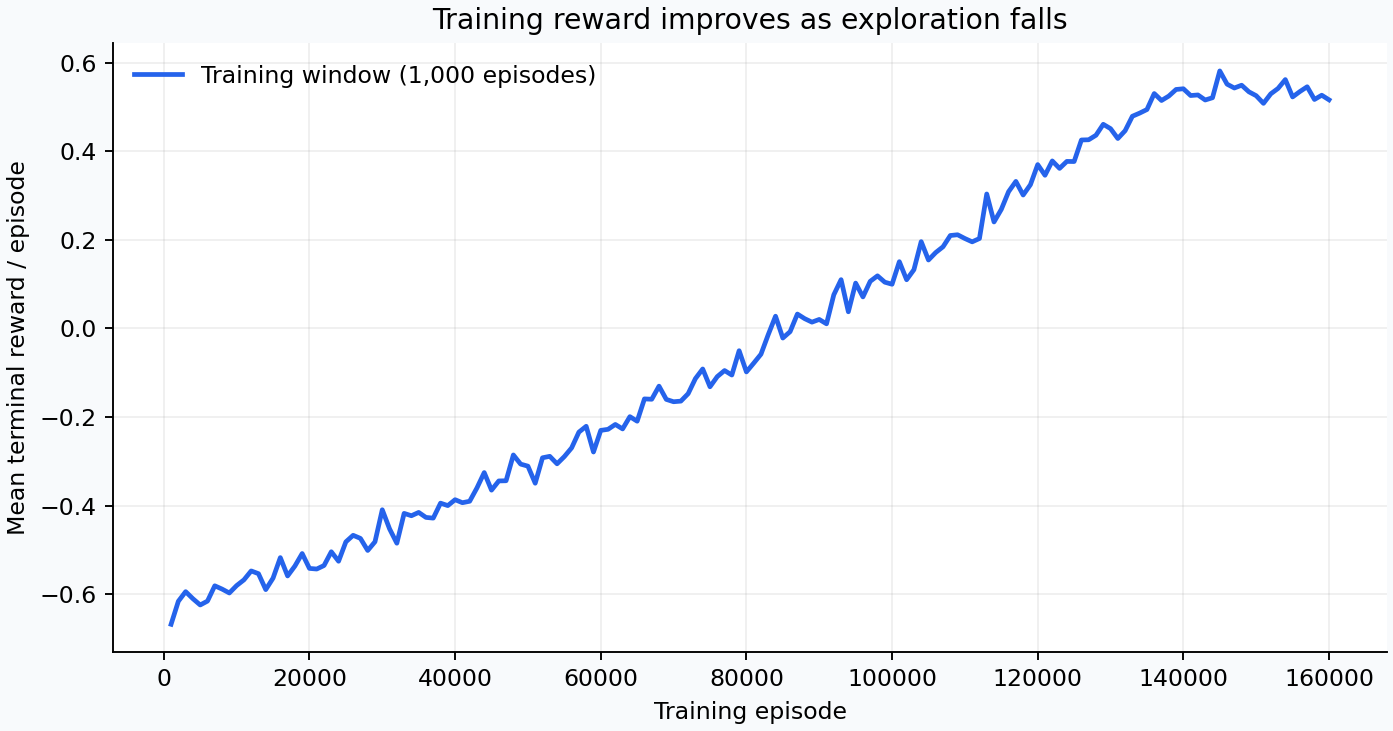

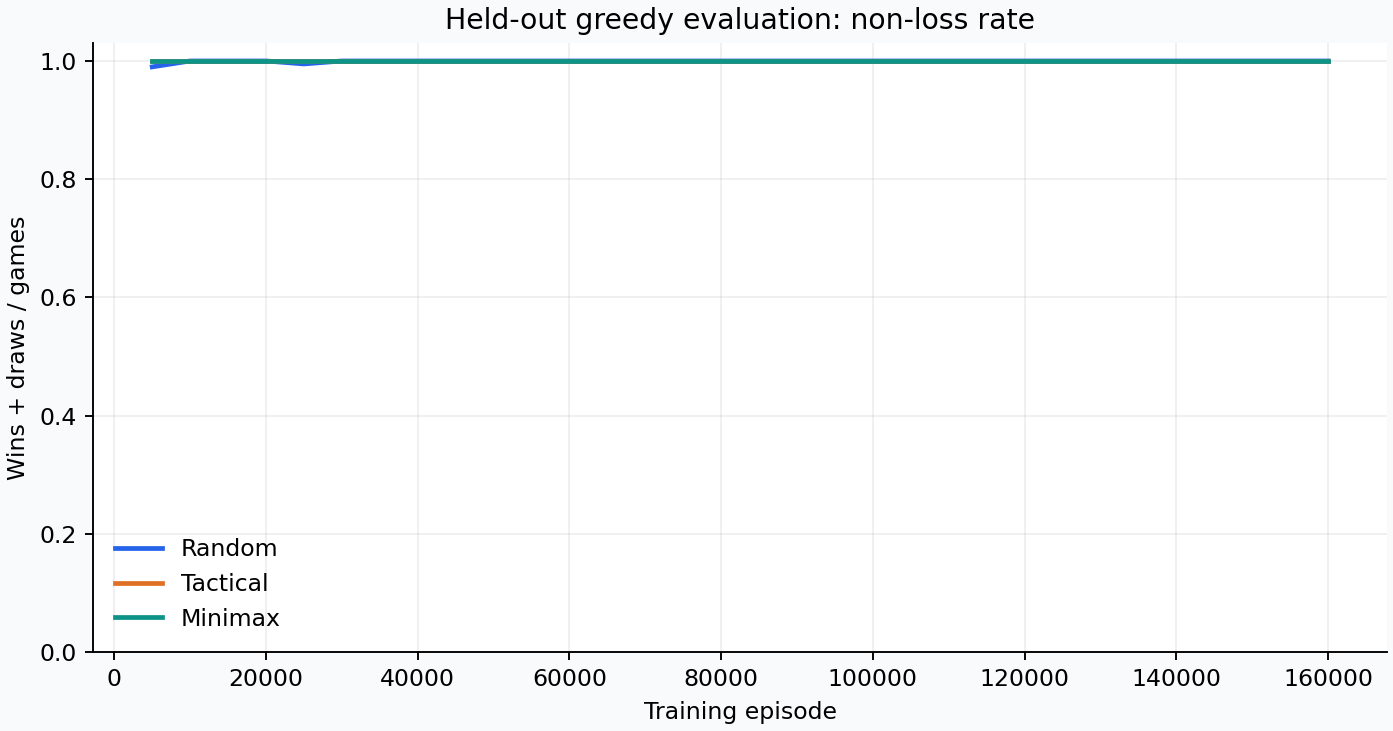

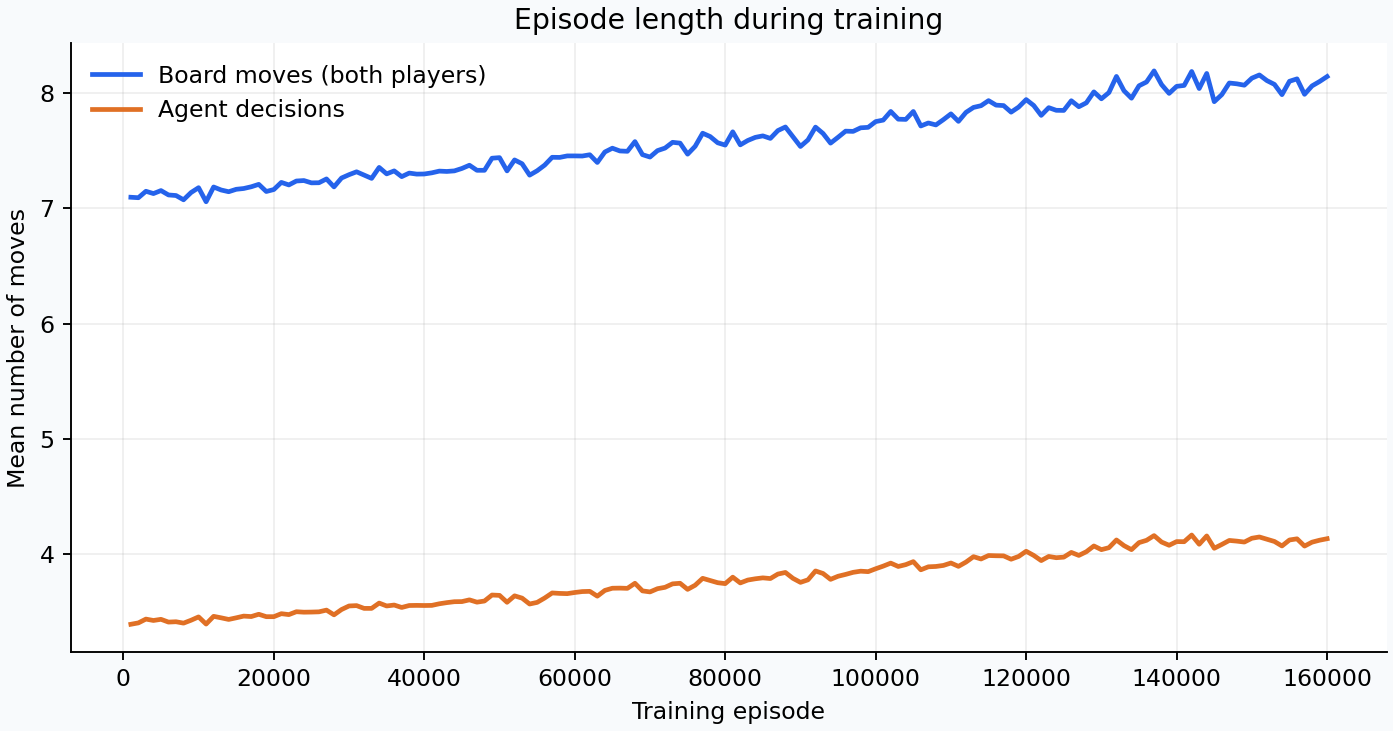

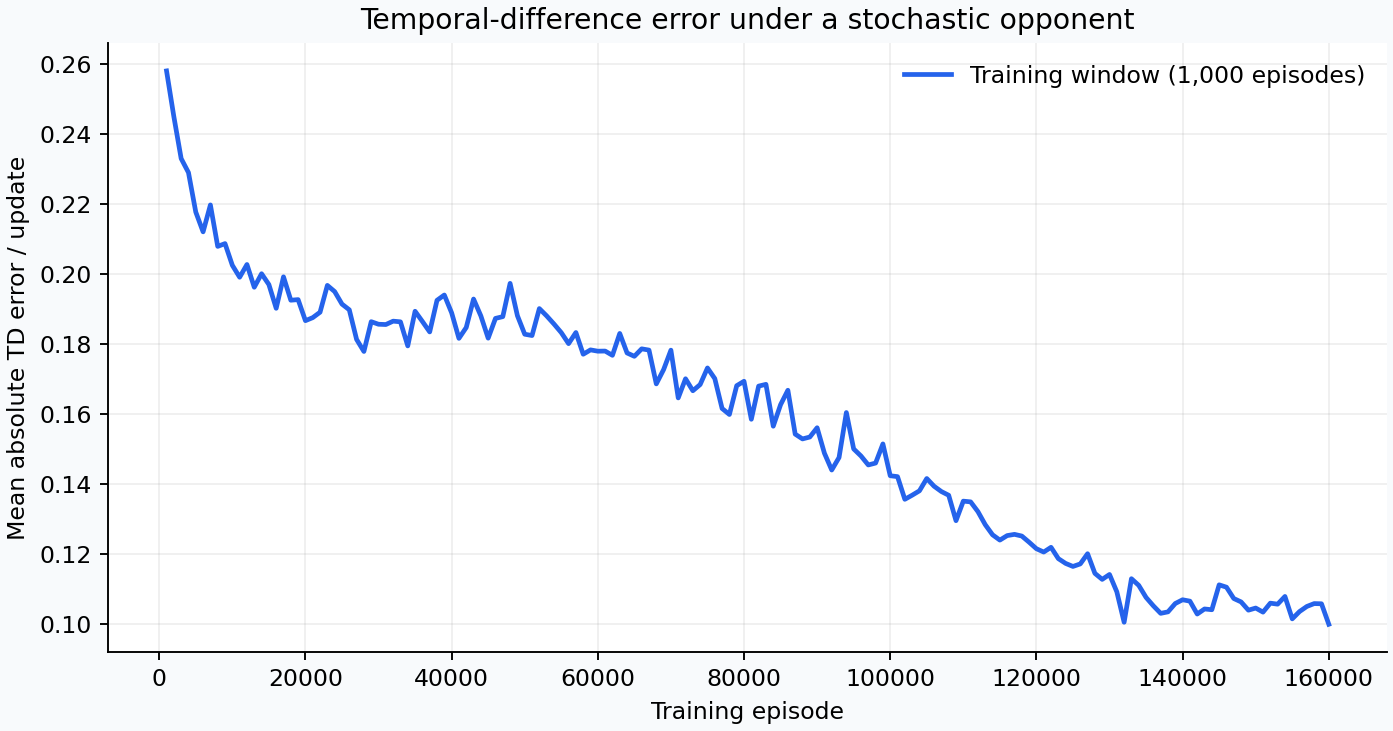

In [5]:
for filename in ("reward_vs_episode.png", "success_vs_episode.png", "steps_vs_episode.png", "td_error_vs_episode.png"):
    display(Image(filename=str(ARTIFACTS / "plots" / filename)))


### 6. Read the Q-learning implementation
The update is `Q(s,a) ← Q(s,a) + α [r + γ max_legal Q(s′,a′) − Q(s,a)]`. The actual implementation below is the one used by this experiment.

In [6]:
import inspect
from tictactoe.agent import QLearningAgent
print(inspect.getsource(QLearningAgent.update))


    def update(self, state: str, action: int, reward: float,
               next_state: str | None, done: bool) -> float:
        """Q <- Q + alpha * [r + gamma * max_legal Q(next) - Q].

        A transition contains an agent move plus an opponent reply, so the next
        nonterminal state is always the SAME agent's next decision. Terminal
        transitions never bootstrap. Returns the absolute temporal-difference error.
        """
        if state[action] != "0":
            raise ValueError("Cannot learn an illegal action.")
        key, permutation = canonicalize(state)
        values = self.q.setdefault(key, [0.0] * 9)
        canonical_action = permutation[action]
        target = reward
        if not done:
            if next_state is None:
                raise ValueError("A nonterminal update needs a next state.")
            next_values = self.values(next_state)
            actions = [a for a, cell in enumerate(next_state) if cell == "0"]
            if not actions:
   

### 7. Verify the rules and learner
These checks cover all winning lines, illegal-action masking, terminal and nonterminal updates, symmetry/export agreement, and deterministic training.

In [7]:
import subprocess
check = subprocess.run([sys.executable, "-m", "unittest", "discover", "-s", "tests", "-v"],
                       text=True, capture_output=True)
print(check.stdout + check.stderr)
assert check.returncode == 0, "A verification check failed"


test_export_and_reload_preserve_values_in_every_orientation (test_rl.LearningTests.test_export_and_reload_preserve_values_in_every_orientation) ... ok
test_nonterminal_update_masks_illegal_next_actions (test_rl.LearningTests.test_nonterminal_update_masks_illegal_next_actions) ... ok
test_policy_masks_occupied_actions_and_randomizes_ties (test_rl.LearningTests.test_policy_masks_occupied_actions_and_randomizes_ties) ... ok
test_terminal_update_never_bootstraps (test_rl.LearningTests.test_terminal_update_never_bootstraps) ... ok
test_training_is_reproducible_and_evaluation_is_nonmutating (test_rl.LearningTests.test_training_is_reproducible_and_evaluation_is_nonmutating) ... ok
test_all_eight_winning_lines_for_both_players (test_rl.RulesTests.test_all_eight_winning_lines_for_both_players) ... ok
test_draw_and_legal_action_mask (test_rl.RulesTests.test_draw_and_legal_action_mask) ... ok
test_minimax_empty_board_draw_and_forced_block (test_rl.RulesTests.test_minimax_empty_board_draw_and_forc

### 8. Play the trained agent offline
Choose X or O, compare against the random baseline, and reveal Q-values. The iframe contains the complete UI and model. You can also open the generated HTML directly in any modern browser.

In [8]:
from scripts.build_offline import build
import html
offline_path = build(WORK)
game_html = offline_path.read_text(encoding="utf-8")
display(HTML('<iframe title="Offline Q-learning Tic Tac Toe" sandbox="allow-scripts" '
             'style="width:100%;height:1100px;border:0;border-radius:16px" srcdoc="'
             + html.escape(game_html, quote=True) + '"></iframe>'))
print("Open this file directly to play:", offline_path)


Offline game: C:\Users\Shreejay\AppData\Local\Temp\tic_tac_toe_qlearning_8usu921t\TicTacToe_Offline.html (519,388 bytes)


C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


Open this file directly to play: C:\Users\Shreejay\AppData\Local\Temp\tic_tac_toe_qlearning_8usu921t\TicTacToe_Offline.html


### 9. Saved outputs and viva preparation
The local experiment folder contains `artifacts/q_table.json`, `training_summary.json`, `evaluation.json`, both CSV logs, four graphs, and `TicTacToe_Offline.html`.

**Why Q-learning?** The state space is small enough for a table; the algorithm learns action values from interaction without a transition model.

**Why exclude occupied squares?** They are not valid actions; including their values in the maximum can corrupt the update.

**Why reward a draw?** A draw is a safe outcome against perfect play. It receives 0.3, below a win's 1 and above a loss's -1.

**What does epsilon do?** It balances exploration with exploitation during training. Deployment uses epsilon 0 and random ties.

**Is minimax deployed?** No. It is a training opponent and evaluation benchmark only.

**What are the limits?** This is a finite board game, not a real-world application benchmark. One training seed is reported. Constant alpha and finite episodes do not establish the general convergence theorem. Unseen states fall back to uniform legal ties.

References: [Sutton and Barto, 2018](https://mitpress.mit.edu/9780262039246/reinforcement-learning/); [Watkins and Dayan, 1992](https://www.gatsby.ucl.ac.uk/~dayan/papers/cjch.pdf).
